# Phase 1. 데이터 탐색 (EDA)

**목적**: Phase 0에서 통합한 데이터를 탐색하여 이후 단계(전처리, Feature Engineering, 이상 탐지)의 의사결정 근거를 마련한다.

**입력 데이터**: `data/processed/all_data.parquet` (16,868,714행)

**출력 데이터**: 없음 (의사결정 사항만 도출)

**주요 확인 사항**:
1. 기초 통계 (행 수 추이, 종별 분포)
2. 사용량 분포 (종별별 시간대 패턴, 극단값, 제로 비율)
3. 시계열 패턴 (대표 설비, 평일/주말, 계절성, NaN 분포)
4. 외부 변수(기온) 활용 가능성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

HOUR_COLS = [f'{i}시' for i in range(1, 25)]
FIG_DIR = '../outputs/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# 데이터 로드
df = pd.read_parquet('../data/processed/all_data.parquet')
df['날짜'] = pd.to_datetime(df['날짜'])
print(f'shape: {df.shape}')
print(f'날짜 범위: {df["날짜"].min().date()} ~ {df["날짜"].max().date()}')
print(f'종별: {df["종별"].unique()}')
print(f'설비 수: {df["설치"].nunique():,}')

shape: (16868714, 39)
날짜 범위: 2021-01-01 ~ 2025-12-31


종별: ['업무용' '주택용' '공공용' '냉수용']


설비 수: 10,126


## 1-1. 기초 통계 확인

### 연도별·월별 행 수 추이

=== 연도별·월별 행 수 ===
월         1       2       3       4       5       6       7       8       9       10      11      12
연도                                                                                                  
2021  262586  238755  264777  257663  267198  259608  269633  270680  263145  272473  264442  274080
2022  274668  249025  275453  266774  276439  267811  276531  277070  268981  279006  271237  282142
2023  283507  256806  285184  276836  285990  276834  287460  288289  279551  289128  280275  290076
2024  290220  271693  290686  282460  294473  286528  296988  297430  288025  297935  288992  299463
2025  300383  272220  302374  293139  302994  293691  303597  304616  295238  305083  295192  305181

연도별 합계:
연도
2021    3165040
2022    3265137
2023    3379936
2024    3484893
2025    3573708



=== 연도별 설비(설치) 수 ===
연도
2021    8907
2022    9208
2023    9416
2024    9720
2025    9900


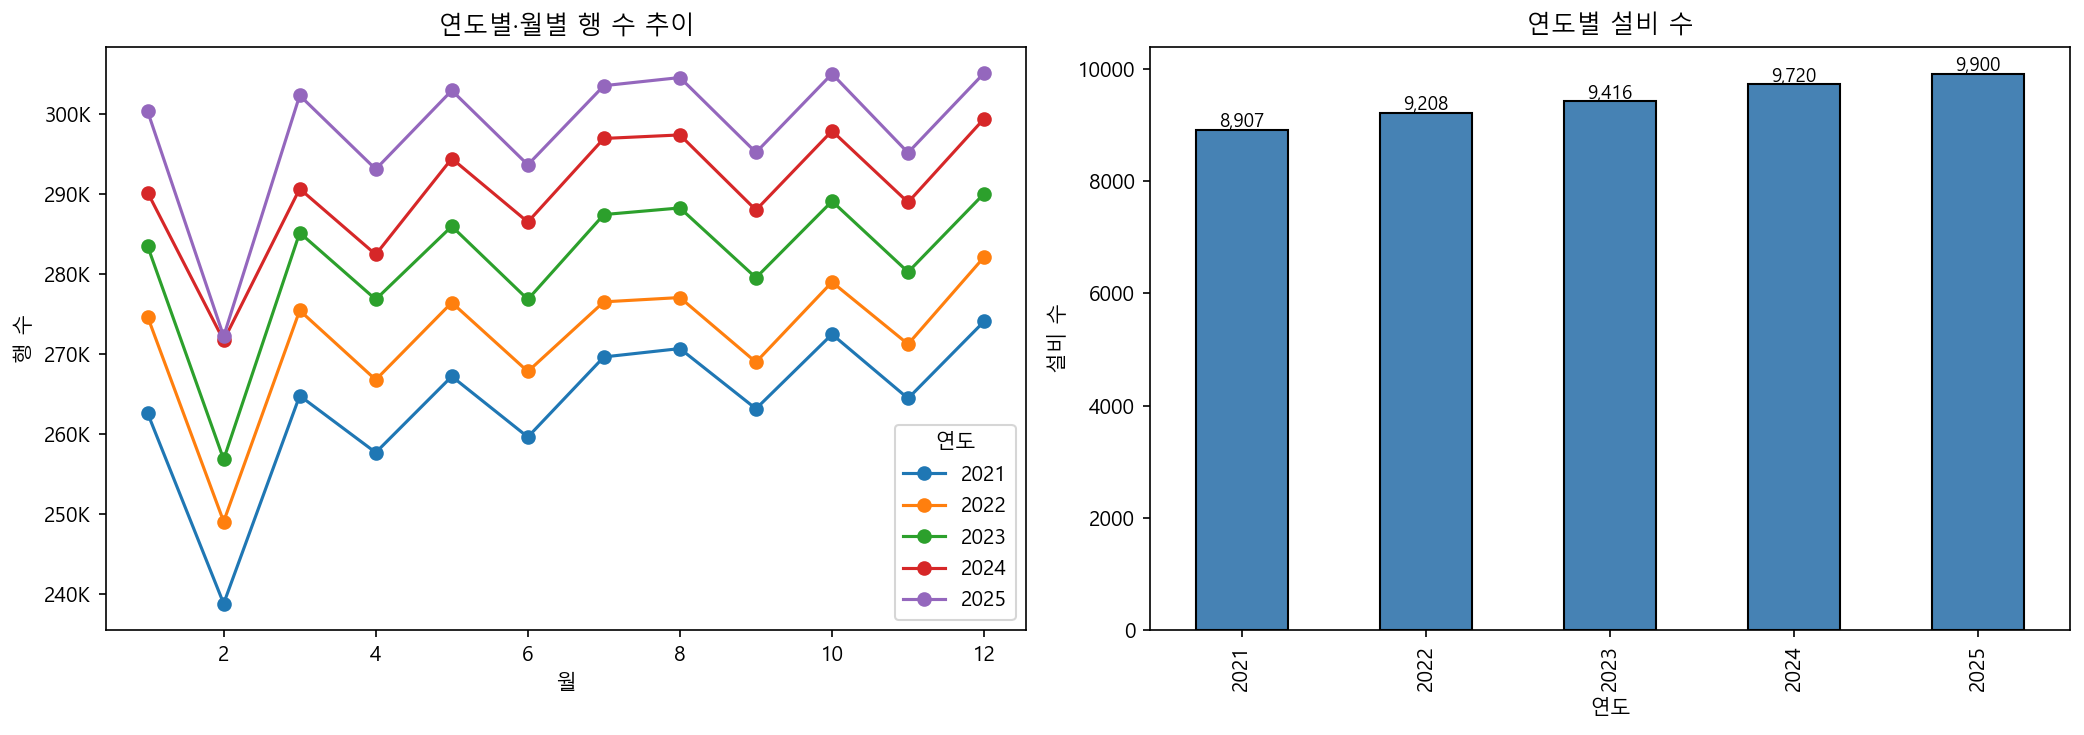

In [2]:
# 연도별·월별 행 수
ym_counts = df.groupby(['연도', '월']).size().unstack(fill_value=0)
print('=== 연도별·월별 행 수 ===')
print(ym_counts.to_string())
print(f'\n연도별 합계:\n{ym_counts.sum(axis=1).to_string()}')

# 연도별 설비 수
inst_by_year = df.groupby('연도')['설치'].nunique()
print(f'\n=== 연도별 설비(설치) 수 ===')
print(inst_by_year.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ym_counts.T.plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title('연도별·월별 행 수 추이')
axes[0].set_xlabel('월')
axes[0].set_ylabel('행 수')
axes[0].legend(title='연도')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

inst_by_year.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('연도별 설비 수')
axes[1].set_ylabel('설비 수')
axes[1].set_xlabel('연도')
for i, v in enumerate(inst_by_year):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_yearly_monthly_counts.png', bbox_inches='tight')
plt.show()

### 종별 비율 및 분포

=== 종별 행 수 및 비율 ===
  주택용:  8,399,121행  (49.8%)
  업무용:  6,468,701행  (38.3%)
  공공용:  1,788,904행  (10.6%)
  냉수용:    211,988행  (1.3%)



=== 종별 설비 수 ===
종별
공공용    1089
냉수용     117
업무용    4081
주택용    4839



=== 연도별 종별 설비 수 ===
종별     공공용  냉수용   업무용   주택용
연도                         
2021  1001  117  3304  4485
2022   996  117  3487  4608
2023   995  117  3630  4674
2024   992  117  3881  4730
2025  1022  117  3983  4778


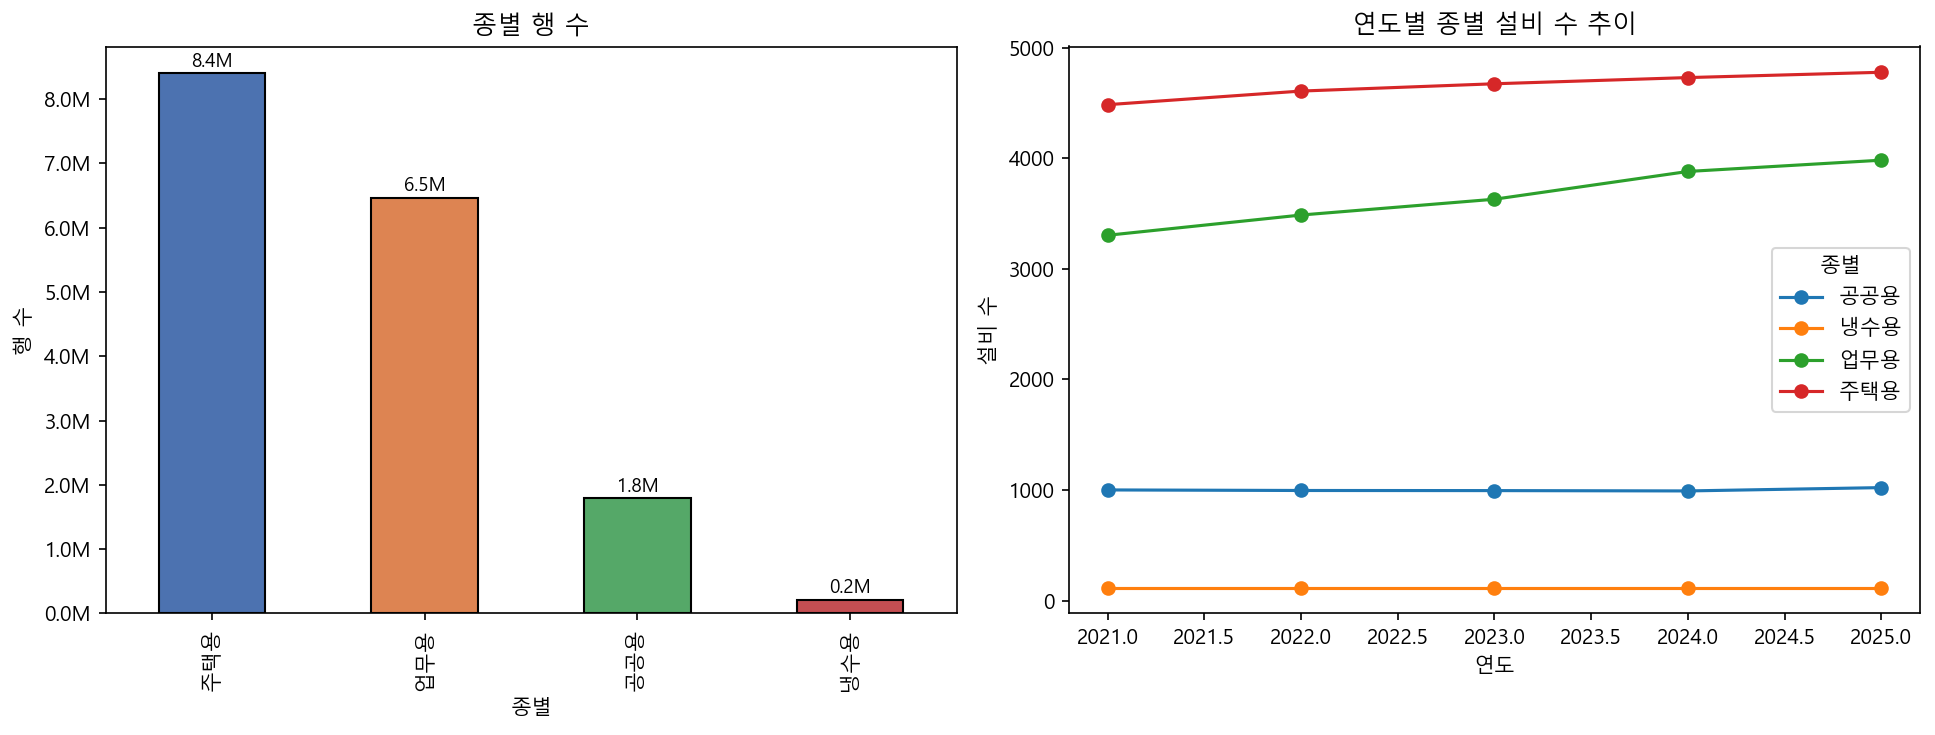

In [3]:
# 종별 분포
type_counts = df['종별'].value_counts()
type_pct = (type_counts / len(df) * 100).round(1)
print('=== 종별 행 수 및 비율 ===')
for t in type_counts.index:
    print(f'  {t}: {type_counts[t]:>10,}행  ({type_pct[t]}%)')

# 종별별 설비 수
type_inst = df.groupby('종별')['설치'].nunique()
print('\n=== 종별 설비 수 ===')
print(type_inst.to_string())

# 연도별 종별 설비 수 추이
type_year_inst = df.groupby(['연도', '종별'])['설치'].nunique().unstack(fill_value=0)
print('\n=== 연도별 종별 설비 수 ===')
print(type_year_inst.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

type_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], edgecolor='black')
axes[0].set_title('종별 행 수')
axes[0].set_ylabel('행 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(type_counts):
    axes[0].text(i, v + 1e5, f'{v/1e6:.1f}M', ha='center', fontsize=9)

type_year_inst.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_title('연도별 종별 설비 수 추이')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('설비 수')
axes[1].legend(title='종별')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_type_distribution.png', bbox_inches='tight')
plt.show()

## 1-2. 사용량 분포 확인

### 종별별 시간대 평균 사용 곡선 (1~24시)

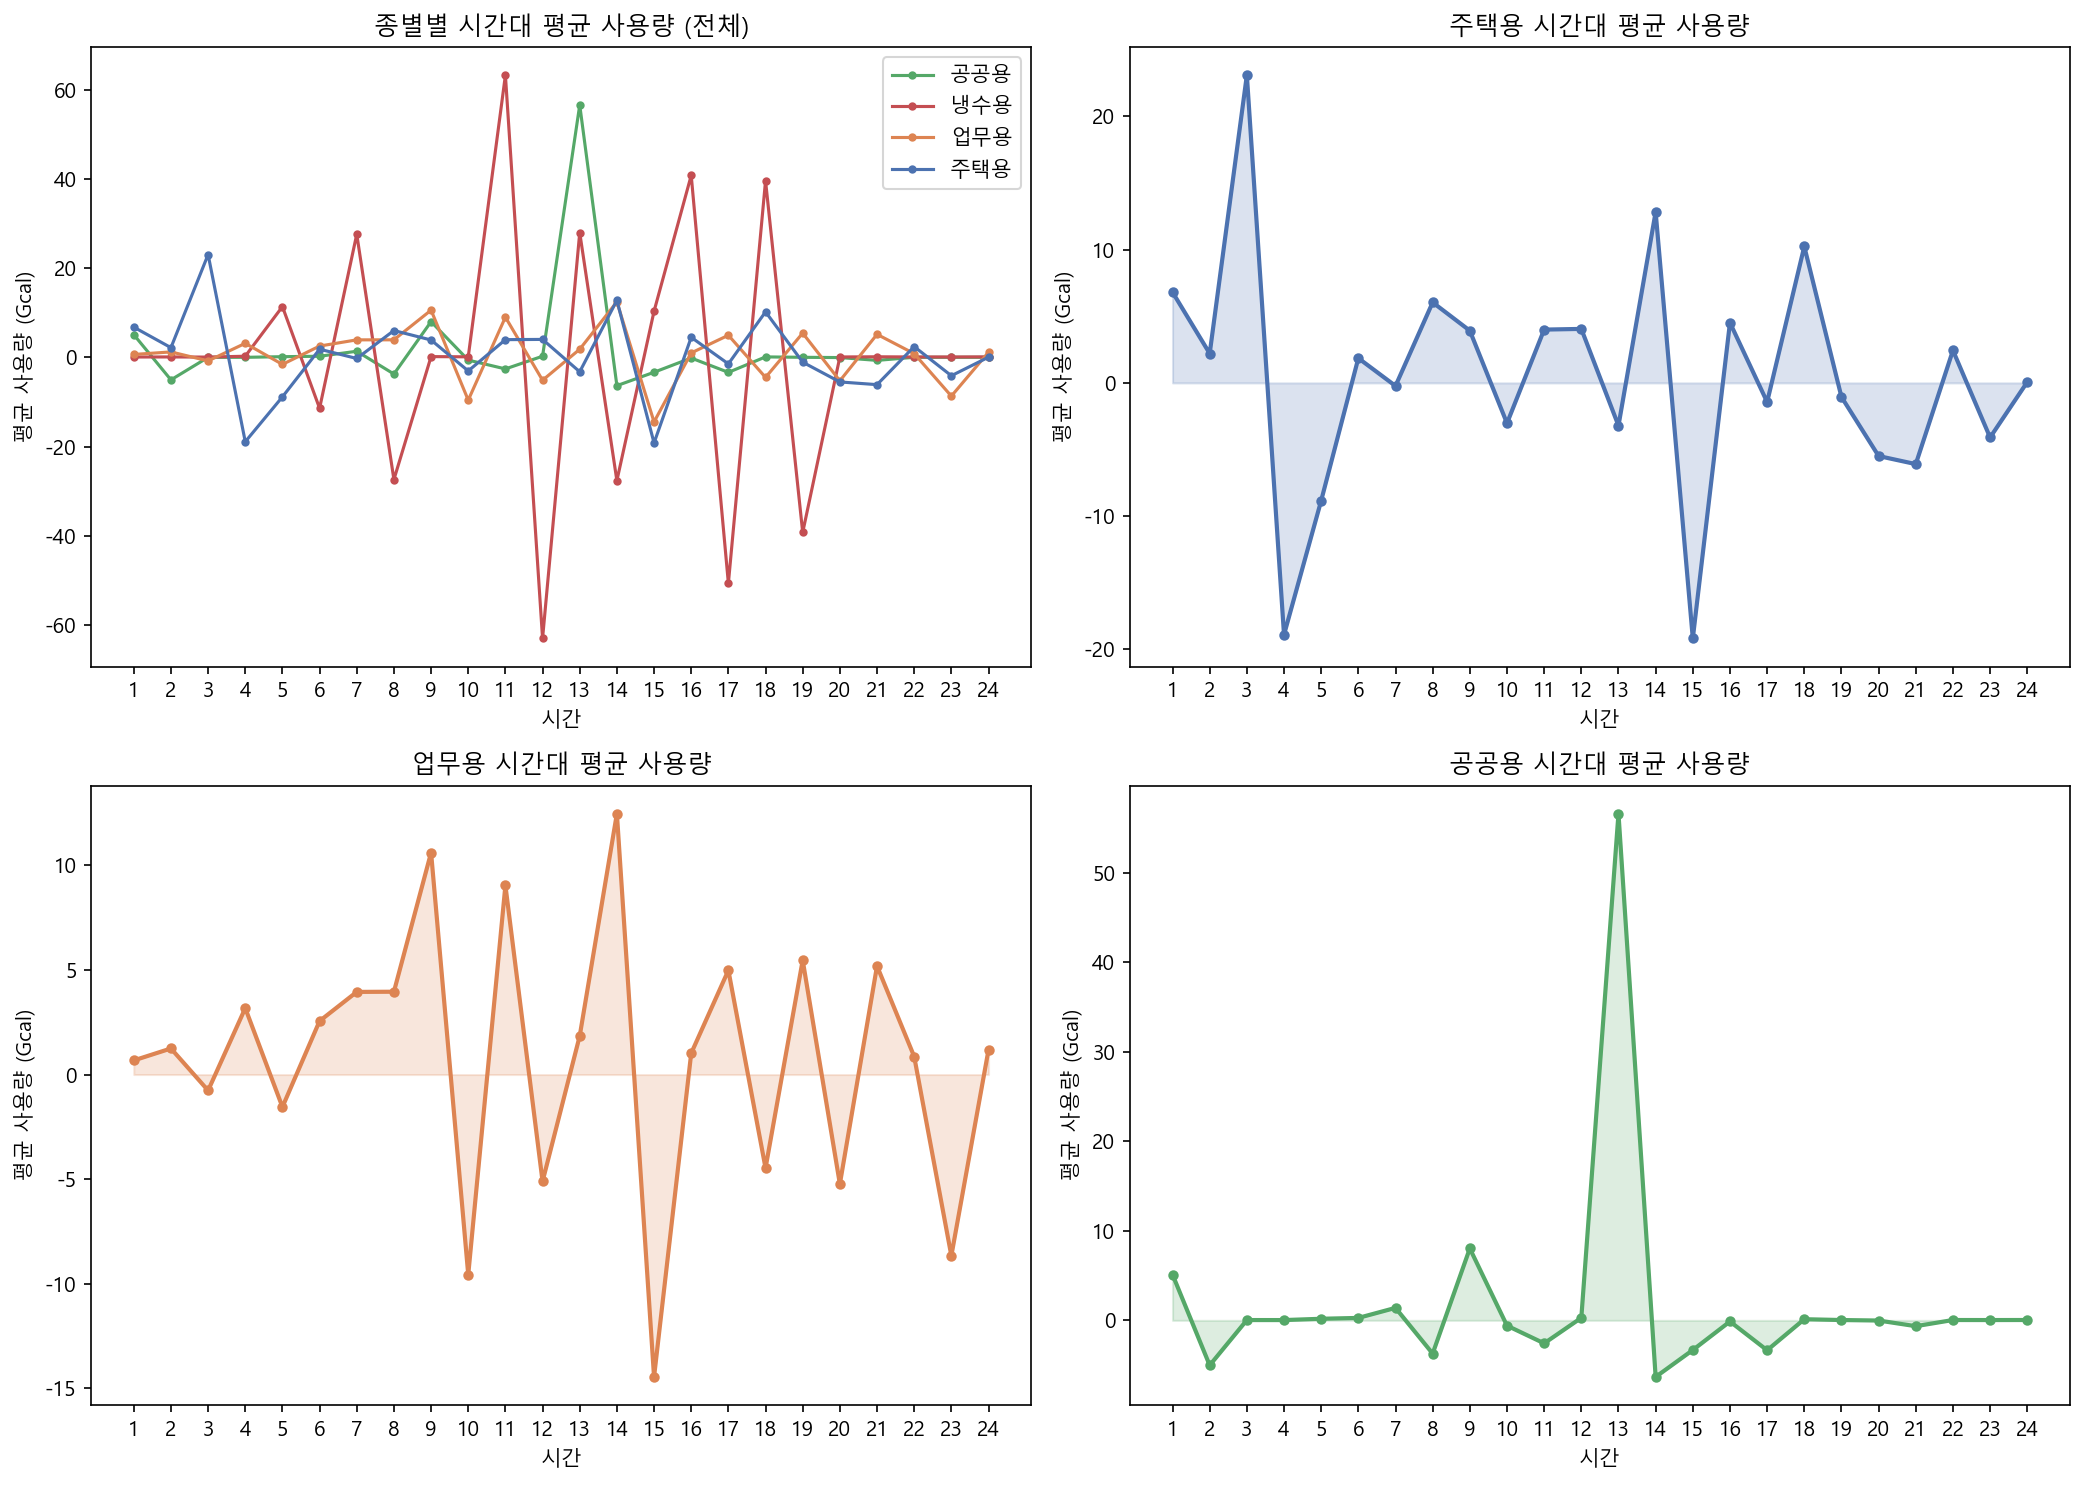


=== 종별별 시간대 평균 사용량 ===
         1시      2시       3시       4시       5시       6시       7시       8시       9시     10시      11시      12시      13시      14시      15시      16시      17시      18시      19시     20시     21시     22시     23시     24시
종별                                                                                                                                                                                                                 
공공용  5.1192 -5.0219   0.0345   0.0330   0.1783   0.2742   1.3956  -3.7136   8.0366 -0.5905  -2.5683   0.2846  56.6264  -6.3206  -3.3139  -0.1253  -3.3398   0.1297   0.0376 -0.0189 -0.6496  0.0391  0.0351  0.0409
냉수용  0.1024  0.1205   0.0862   0.2803  11.4110 -11.4020  27.6470 -27.3808   0.1964  0.1459  63.3168 -63.0253  28.0091 -27.6271  10.3736  40.8431 -50.6556  39.6316 -39.2440  0.1141  0.1540  0.1160  0.1116  0.1334
업무용  0.6753  1.2467  -0.7623   3.1761  -1.5528   2.5600   3.9522   3.9607  10.6143 -9.5705   9.0439  -5.1091   1.8475  12.4750 -

In [4]:
# 종별별 시간대 평균 사용 곡선
hourly_by_type = df.groupby('종별')[HOUR_COLS].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'주택용': '#4C72B0', '업무용': '#DD8452', '공공용': '#55A868', '냉수용': '#C44E52'}

# 전체 비교
ax = axes[0, 0]
for t in hourly_by_type.index:
    ax.plot(range(1, 25), hourly_by_type.loc[t], marker='o', markersize=3, label=t, color=colors.get(t))
ax.set_title('종별별 시간대 평균 사용량 (전체)')
ax.set_xlabel('시간')
ax.set_ylabel('평균 사용량 (Gcal)')
ax.legend()
ax.set_xticks(range(1, 25))

# 종별별 개별 차트
for idx, t in enumerate(['주택용', '업무용', '공공용']):
    ax = axes[(idx + 1) // 2, (idx + 1) % 2]
    ax.plot(range(1, 25), hourly_by_type.loc[t], marker='o', markersize=4, color=colors[t], linewidth=2)
    ax.fill_between(range(1, 25), hourly_by_type.loc[t], alpha=0.2, color=colors[t])
    ax.set_title(f'{t} 시간대 평균 사용량')
    ax.set_xlabel('시간')
    ax.set_ylabel('평균 사용량 (Gcal)')
    ax.set_xticks(range(1, 25))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_hourly_pattern_by_type.png', bbox_inches='tight')
plt.show()

print('\n=== 종별별 시간대 평균 사용량 ===')
print(hourly_by_type.round(4).to_string())

### 난방시즌 vs 비난방시즌 시간대 패턴 비교

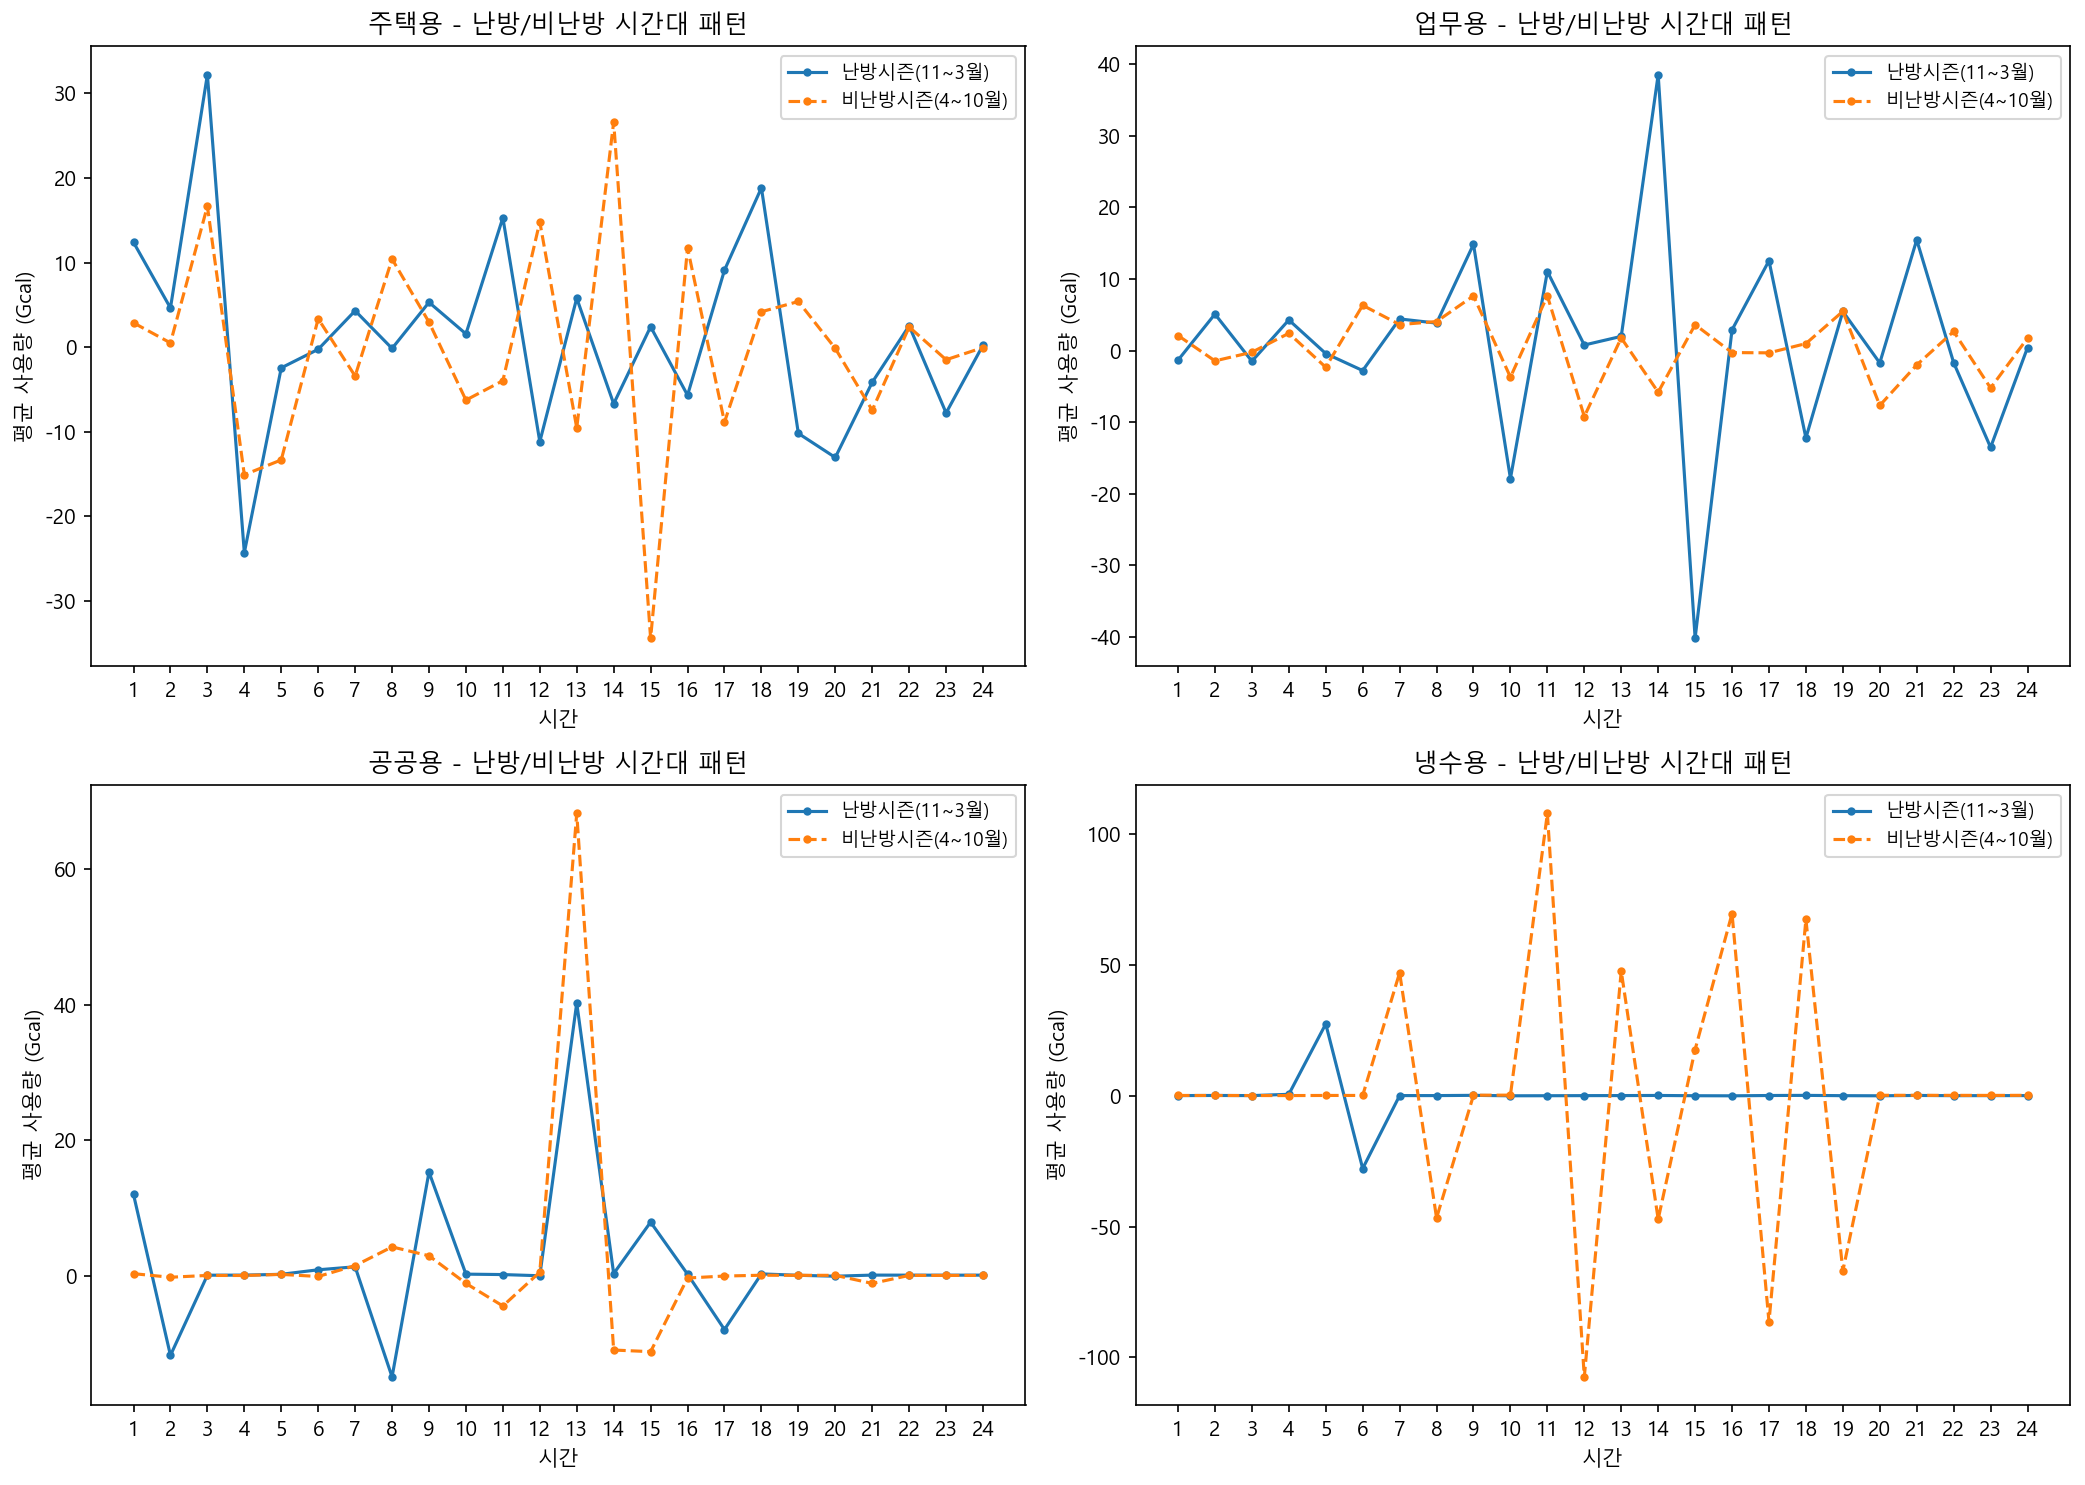

In [5]:
# 난방시즌 vs 비난방시즌 종별별 시간대 패턴
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, t in enumerate(['주택용', '업무용', '공공용', '냉수용']):
    ax = axes[idx // 2, idx % 2]
    sub = df[df['종별'] == t]
    for season, label, ls in [(True, '난방시즌(11~3월)', '-'), (False, '비난방시즌(4~10월)', '--')]:
        vals = sub[sub['난방시즌'] == season][HOUR_COLS].mean()
        ax.plot(range(1, 25), vals, marker='o', markersize=3, label=label, linestyle=ls)
    ax.set_title(f'{t} - 난방/비난방 시간대 패턴')
    ax.set_xlabel('시간')
    ax.set_ylabel('평균 사용량 (Gcal)')
    ax.set_xticks(range(1, 25))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_season_hourly_pattern.png', bbox_inches='tight')
plt.show()

### 총사용량 분포 및 극단값 분석

In [6]:
# 종별별 총사용량 기초 통계
print('=== 종별별 총사용량 기초 통계 ===')
stats = df.groupby('종별')['총사용량'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print(stats.T.round(4).to_string())

# 종별별 percentile 상세
print('\n=== 종별별 주요 percentile ===')
for t in ['주택용', '업무용', '공공용', '냉수용']:
    sub = df[df['종별'] == t]['총사용량']
    pcts = sub.quantile([0.01, 0.05, 0.95, 0.99, 0.999, 0.9999])
    neg_cnt = (sub < 0).sum()
    zero_cnt = (sub == 0).sum()
    print(f'\n{t} (N={len(sub):,}):')
    print(f'  음수: {neg_cnt:,}건 ({neg_cnt/len(sub)*100:.2f}%)')
    print(f'  제로: {zero_cnt:,}건 ({zero_cnt/len(sub)*100:.2f}%)')
    print(f'  percentiles: {pcts.to_dict()}')

=== 종별별 총사용량 기초 통계 ===


종별              공공용         냉수용           업무용           주택용
count  1.788904e+06  211988.000  6.468701e+06  8.399121e+06
mean   4.620780e+01       3.456  1.826550e+01  1.047080e+01
std    5.255020e+04      41.438  1.834063e+04  3.342233e+04
min   -1.178871e+07  -10727.170 -1.993245e+07 -5.683527e+07
25%    0.000000e+00       0.000  0.000000e+00  1.200000e+00
50%    1.300000e-01       0.000  1.800000e-01  3.090000e+00
75%    9.000000e-01       2.700  1.170000e+00  8.170000e+00
90%    3.420000e+00       8.640  3.640000e+00  1.543000e+01
95%    6.570000e+00      18.260  6.790000e+00  2.124000e+01
99%    2.103000e+01      49.440  1.923000e+01  3.593000e+01
99.9%  8.176000e+01      73.740  5.120000e+01  6.340000e+01
max    6.045491e+07    5958.530  1.131915e+07  2.816760e+07

=== 종별별 주요 percentile ===



주택용 (N=8,399,121):
  음수: 749건 (0.01%)
  제로: 145,003건 (1.73%)
  percentiles: {0.01: 0.0, 0.05: 0.27, 0.95: 21.24, 0.99: 35.93, 0.999: 63.4, 0.9999: 101.85999999999999}



업무용 (N=6,468,701):
  음수: 842건 (0.01%)
  제로: 2,420,586건 (37.42%)
  percentiles: {0.01: 0.0, 0.05: 0.0, 0.95: 6.790000000000001, 0.99: 19.23, 0.999: 51.2, 0.9999: 98.6}



공공용 (N=1,788,904):
  음수: 175건 (0.01%)
  제로: 622,560건 (34.80%)
  percentiles: {0.01: 0.0, 0.05: 0.0, 0.95: 6.57, 0.99: 21.03, 0.999: 81.75999999999999, 0.9999: 159.10219399999826}

냉수용 (N=211,988):
  음수: 55건 (0.03%)
  제로: 112,024건 (52.84%)
  percentiles: {0.01: 0.0, 0.05: 0.0, 0.95: 18.26, 0.99: 49.44, 0.999: 73.74, 0.9999: 350.4}


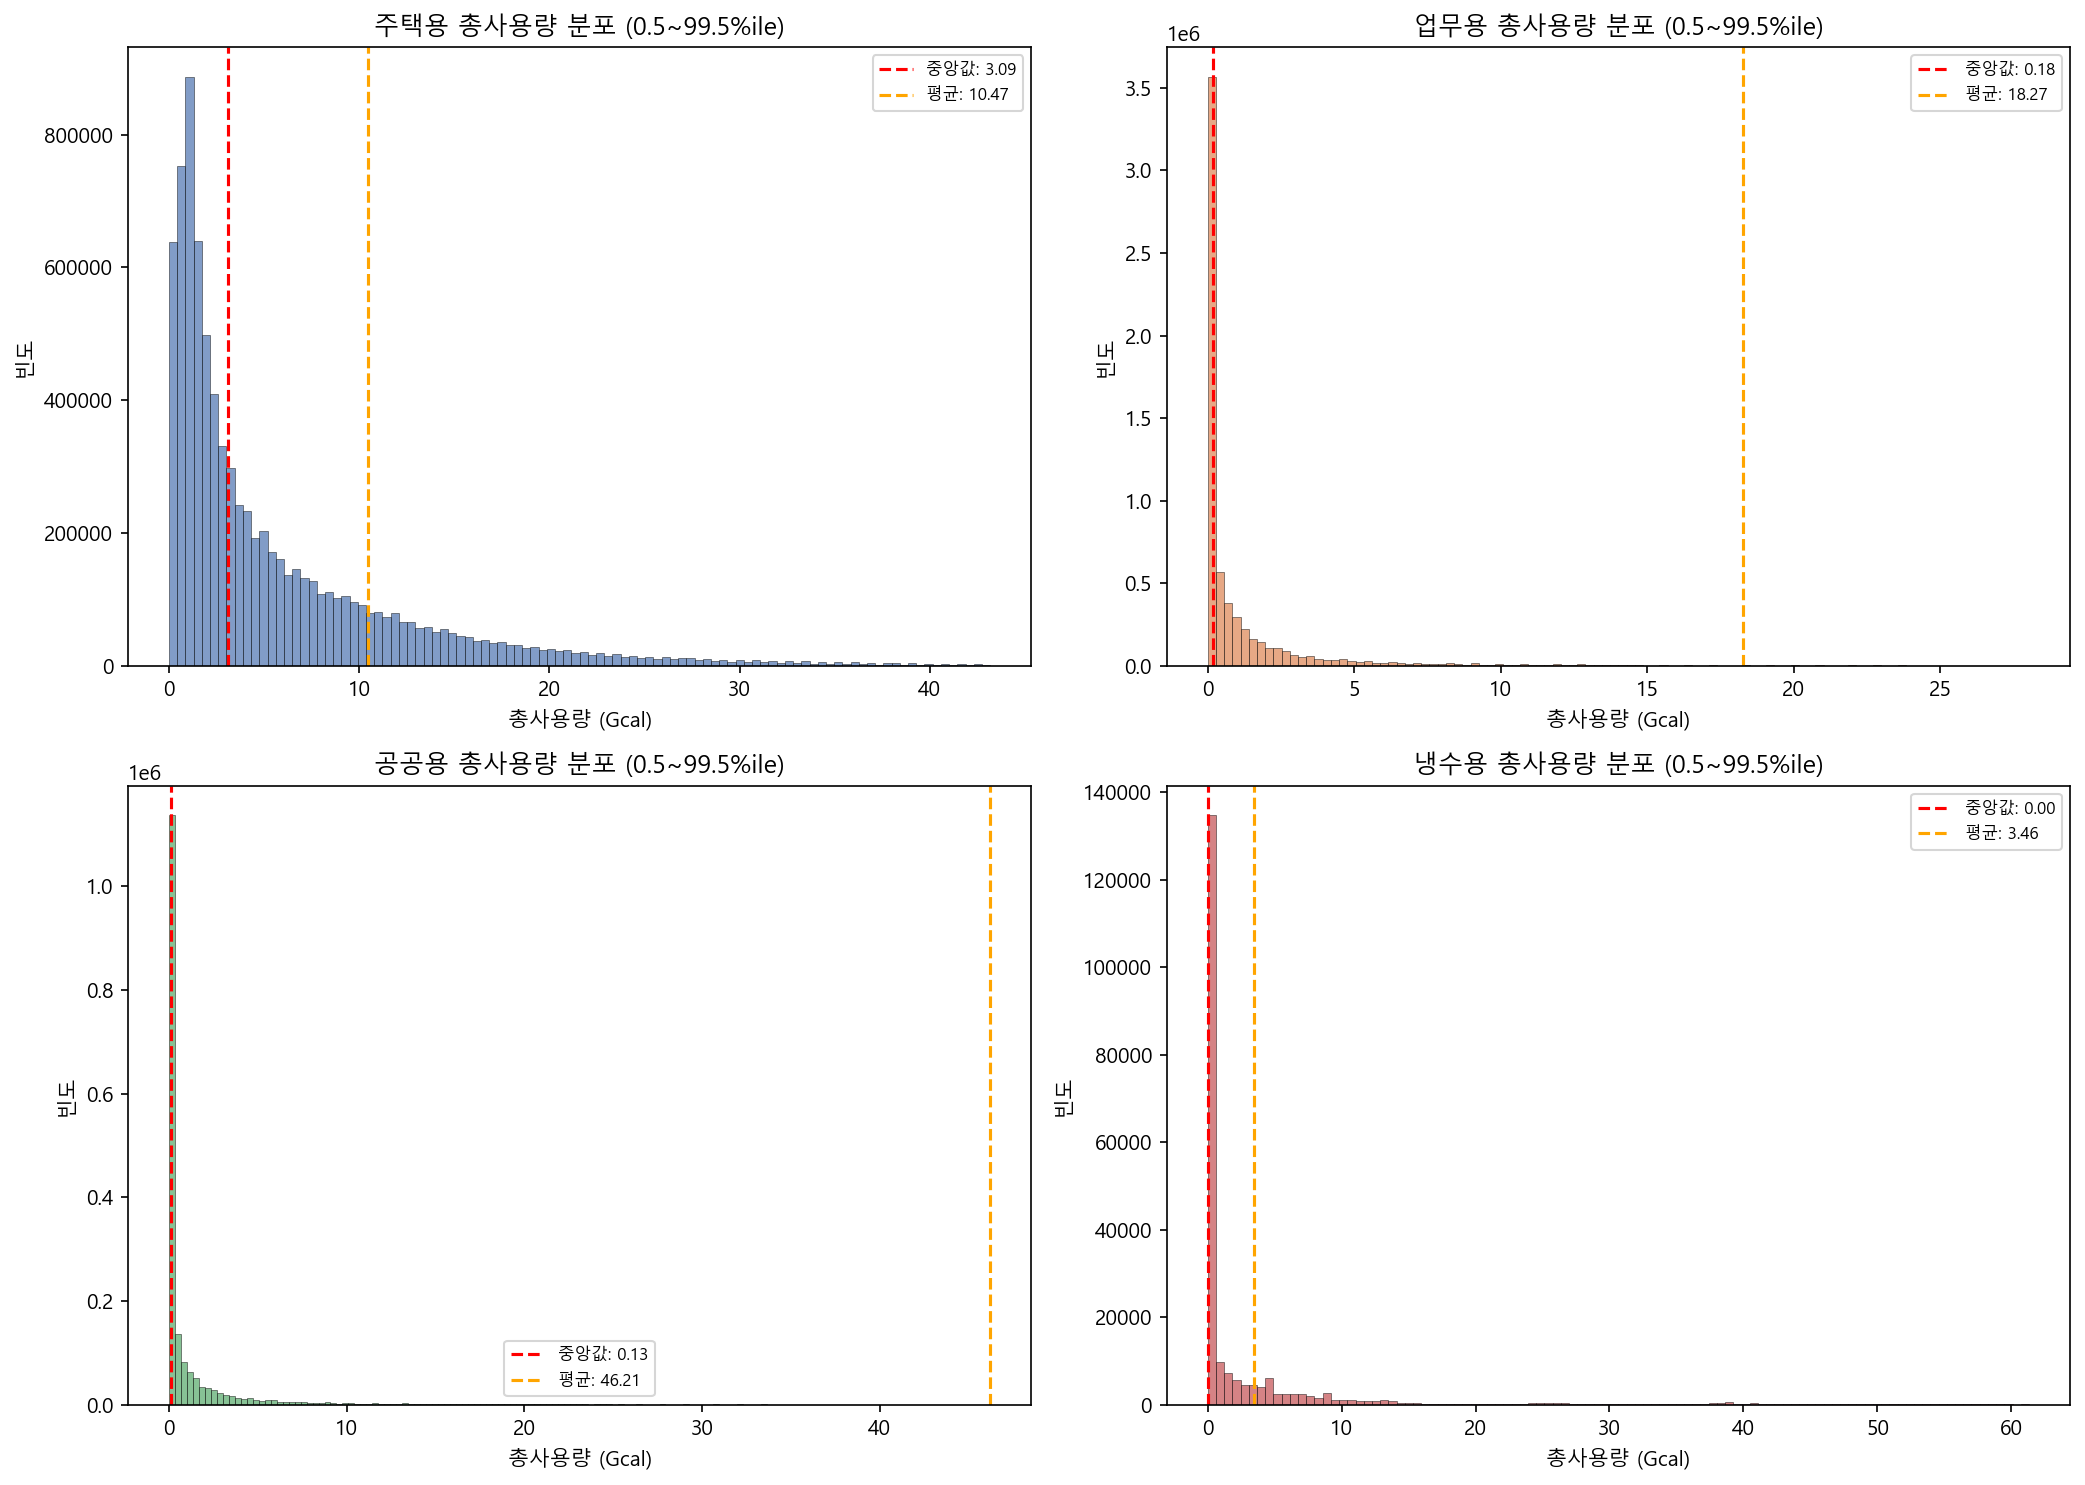

In [7]:
# 종별별 총사용량 분포 (히스토그램, 99.5% 이내로 clip해서 시각화)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, t in enumerate(['주택용', '업무용', '공공용', '냉수용']):
    ax = axes[idx // 2, idx % 2]
    sub = df[df['종별'] == t]['총사용량']
    upper = sub.quantile(0.995)
    lower = sub.quantile(0.005)
    clipped = sub[(sub >= lower) & (sub <= upper)]
    ax.hist(clipped, bins=100, color=list(colors.values())[idx], alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(sub.median(), color='red', linestyle='--', label=f'중앙값: {sub.median():.2f}')
    ax.axvline(sub.mean(), color='orange', linestyle='--', label=f'평균: {sub.mean():.2f}')
    ax.set_title(f'{t} 총사용량 분포 (0.5~99.5%ile)')
    ax.set_xlabel('총사용량 (Gcal)')
    ax.set_ylabel('빈도')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_total_usage_distribution.png', bbox_inches='tight')
plt.show()

### 음수값 상세 분석

In [8]:
# 음수값 상세 분석
neg_mask = (df[HOUR_COLS] < 0).any(axis=1)
neg_rows = df[neg_mask]
print(f'음수값 포함 행 수: {len(neg_rows):,} ({len(neg_rows)/len(df)*100:.2f}%)')
print(f'\n종별별 음수값 포함 행:')
print(neg_rows['종별'].value_counts().to_string())

# 음수값의 크기 분포
neg_vals = df[HOUR_COLS].values[df[HOUR_COLS].values < 0]
print(f'\n음수값 크기 분포:')
print(f'  min: {neg_vals.min():.4f}')
print(f'  median: {np.median(neg_vals):.4f}')
print(f'  mean: {neg_vals.mean():.4f}')
print(f'  max (가장 작은 음수): {neg_vals.max():.4f}')
print(f'  < -1 Gcal: {(neg_vals < -1).sum():,}건')
print(f'  < -10 Gcal: {(neg_vals < -10).sum():,}건')

# 음수값이 있는 행에서 총사용량 분포
print(f'\n음수값 포함 행의 총사용량:')
print(neg_rows['총사용량'].describe().to_string())

# 음수값이 특정 시간대에 집중되는지
neg_by_hour = (df[HOUR_COLS] < 0).sum()
print(f'\n시간대별 음수값 건수:')
print(neg_by_hour.to_string())

음수값 포함 행 수: 6,604 (0.04%)

종별별 음수값 포함 행:
종별
업무용    3435
주택용    2347
공공용     590
냉수용     232



음수값 크기 분포:
  min: -73039997.2600
  median: -105.5450
  mean: -380460.4577
  max (가장 작은 음수): -0.0100
  < -1 Gcal: 5,972건
  < -10 Gcal: 4,830건

음수값 포함 행의 총사용량:
count    6.604000e+03
mean    -3.284788e+04
std      1.174347e+06
min     -5.683527e+07
25%     -3.882500e+00
50%      4.354156e-16
75%      1.750000e+00
max      1.838952e+07



시간대별 음수값 건수:
1시     181
2시     163
3시     167
4시     208
5시     204
6시     205
7시     195
8시     273
9시     282
10시    645
11시    546
12시    414
13시    432
14시    670
15시    513
16시    399
17시    351
18시    330
19시    351
20시    346
21시    358
22시    314
23시    294
24시    221


### 사용량=0 비율 분석 (월별 추이)

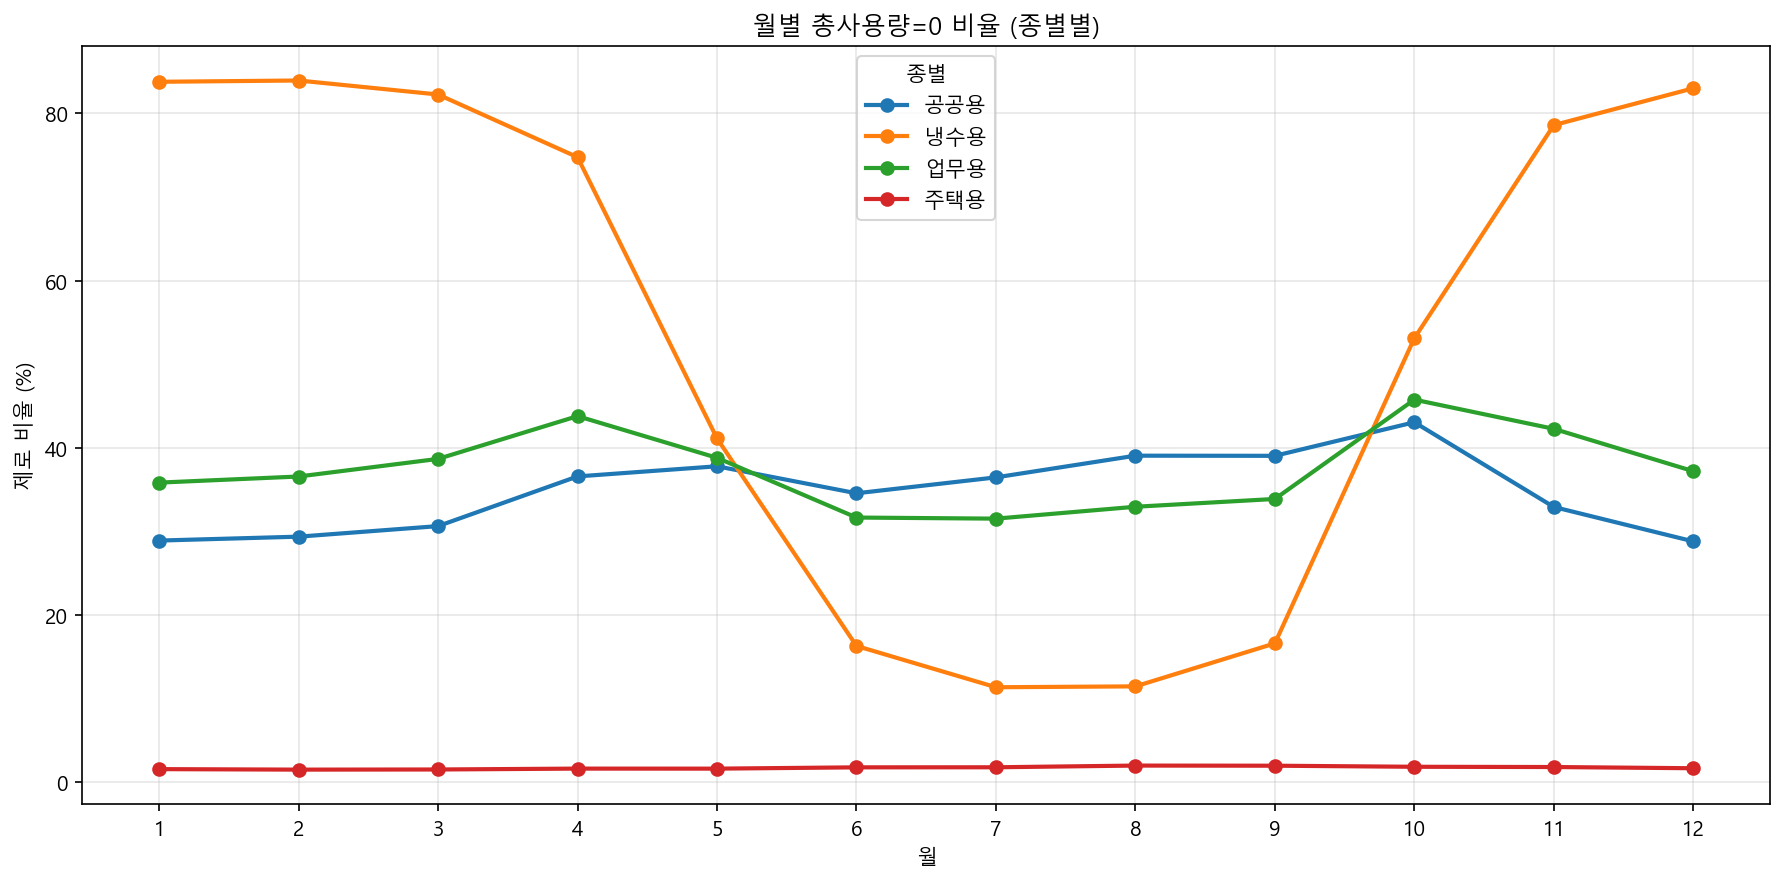

=== 월별 제로 비율(%) ===
종별   공공용   냉수용   업무용  주택용
월                        
1   28.9  83.8  35.8  1.6
2   29.4  83.9  36.6  1.5
3   30.6  82.3  38.7  1.5
4   36.6  74.8  43.8  1.6
5   37.8  41.1  38.8  1.6
6   34.6  16.3  31.7  1.8
7   36.5  11.4  31.5  1.8
8   39.1  11.5  33.0  2.0
9   39.0  16.6  33.9  2.0
10  43.1  53.1  45.8  1.8
11  32.9  78.6  42.3  1.8
12  28.8  83.0  37.2  1.7

전체 제로 행: 3,300,173 (19.6%)


난방시즌 제로 비율: 19.6%


비난방시즌 제로 비율: 19.5%


In [9]:
# 총사용량=0 비율 월별 추이 (종별별)
zero_rate = df.groupby(['월', '종별']).apply(lambda x: (x['총사용량'] == 0).mean() * 100).unstack()

fig, ax = plt.subplots(figsize=(12, 6))
zero_rate.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('월별 총사용량=0 비율 (종별별)')
ax.set_xlabel('월')
ax.set_ylabel('제로 비율 (%)')
ax.set_xticks(range(1, 13))
ax.legend(title='종별')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_zero_rate_monthly.png', bbox_inches='tight')
plt.show()

print('=== 월별 제로 비율(%) ===')
print(zero_rate.round(1).to_string())

# 전체 제로 비율
total_zero = (df['총사용량'] == 0).sum()
print(f'\n전체 제로 행: {total_zero:,} ({total_zero/len(df)*100:.1f}%)')

# 난방시즌 vs 비난방시즌 제로 비율
for season, label in [(True, '난방시즌'), (False, '비난방시즌')]:
    sub = df[df['난방시즌'] == season]
    zr = (sub['총사용량'] == 0).mean() * 100
    print(f'{label} 제로 비율: {zr:.1f}%')

## 1-3. 시계열 패턴 확인

### 대표 설비 일별 총사용량 추이 (종별별 1~2개)

주택용 대표 설비: ['Inst_8406', 'Inst_3937'] (평균 사용량: [4.74 4.74])


업무용 대표 설비: ['Inst_1310', 'Inst_2327'] (평균 사용량: [0.63 0.63])


공공용 대표 설비: ['Inst_3727', 'Inst_4705'] (평균 사용량: [0.46 0.46])


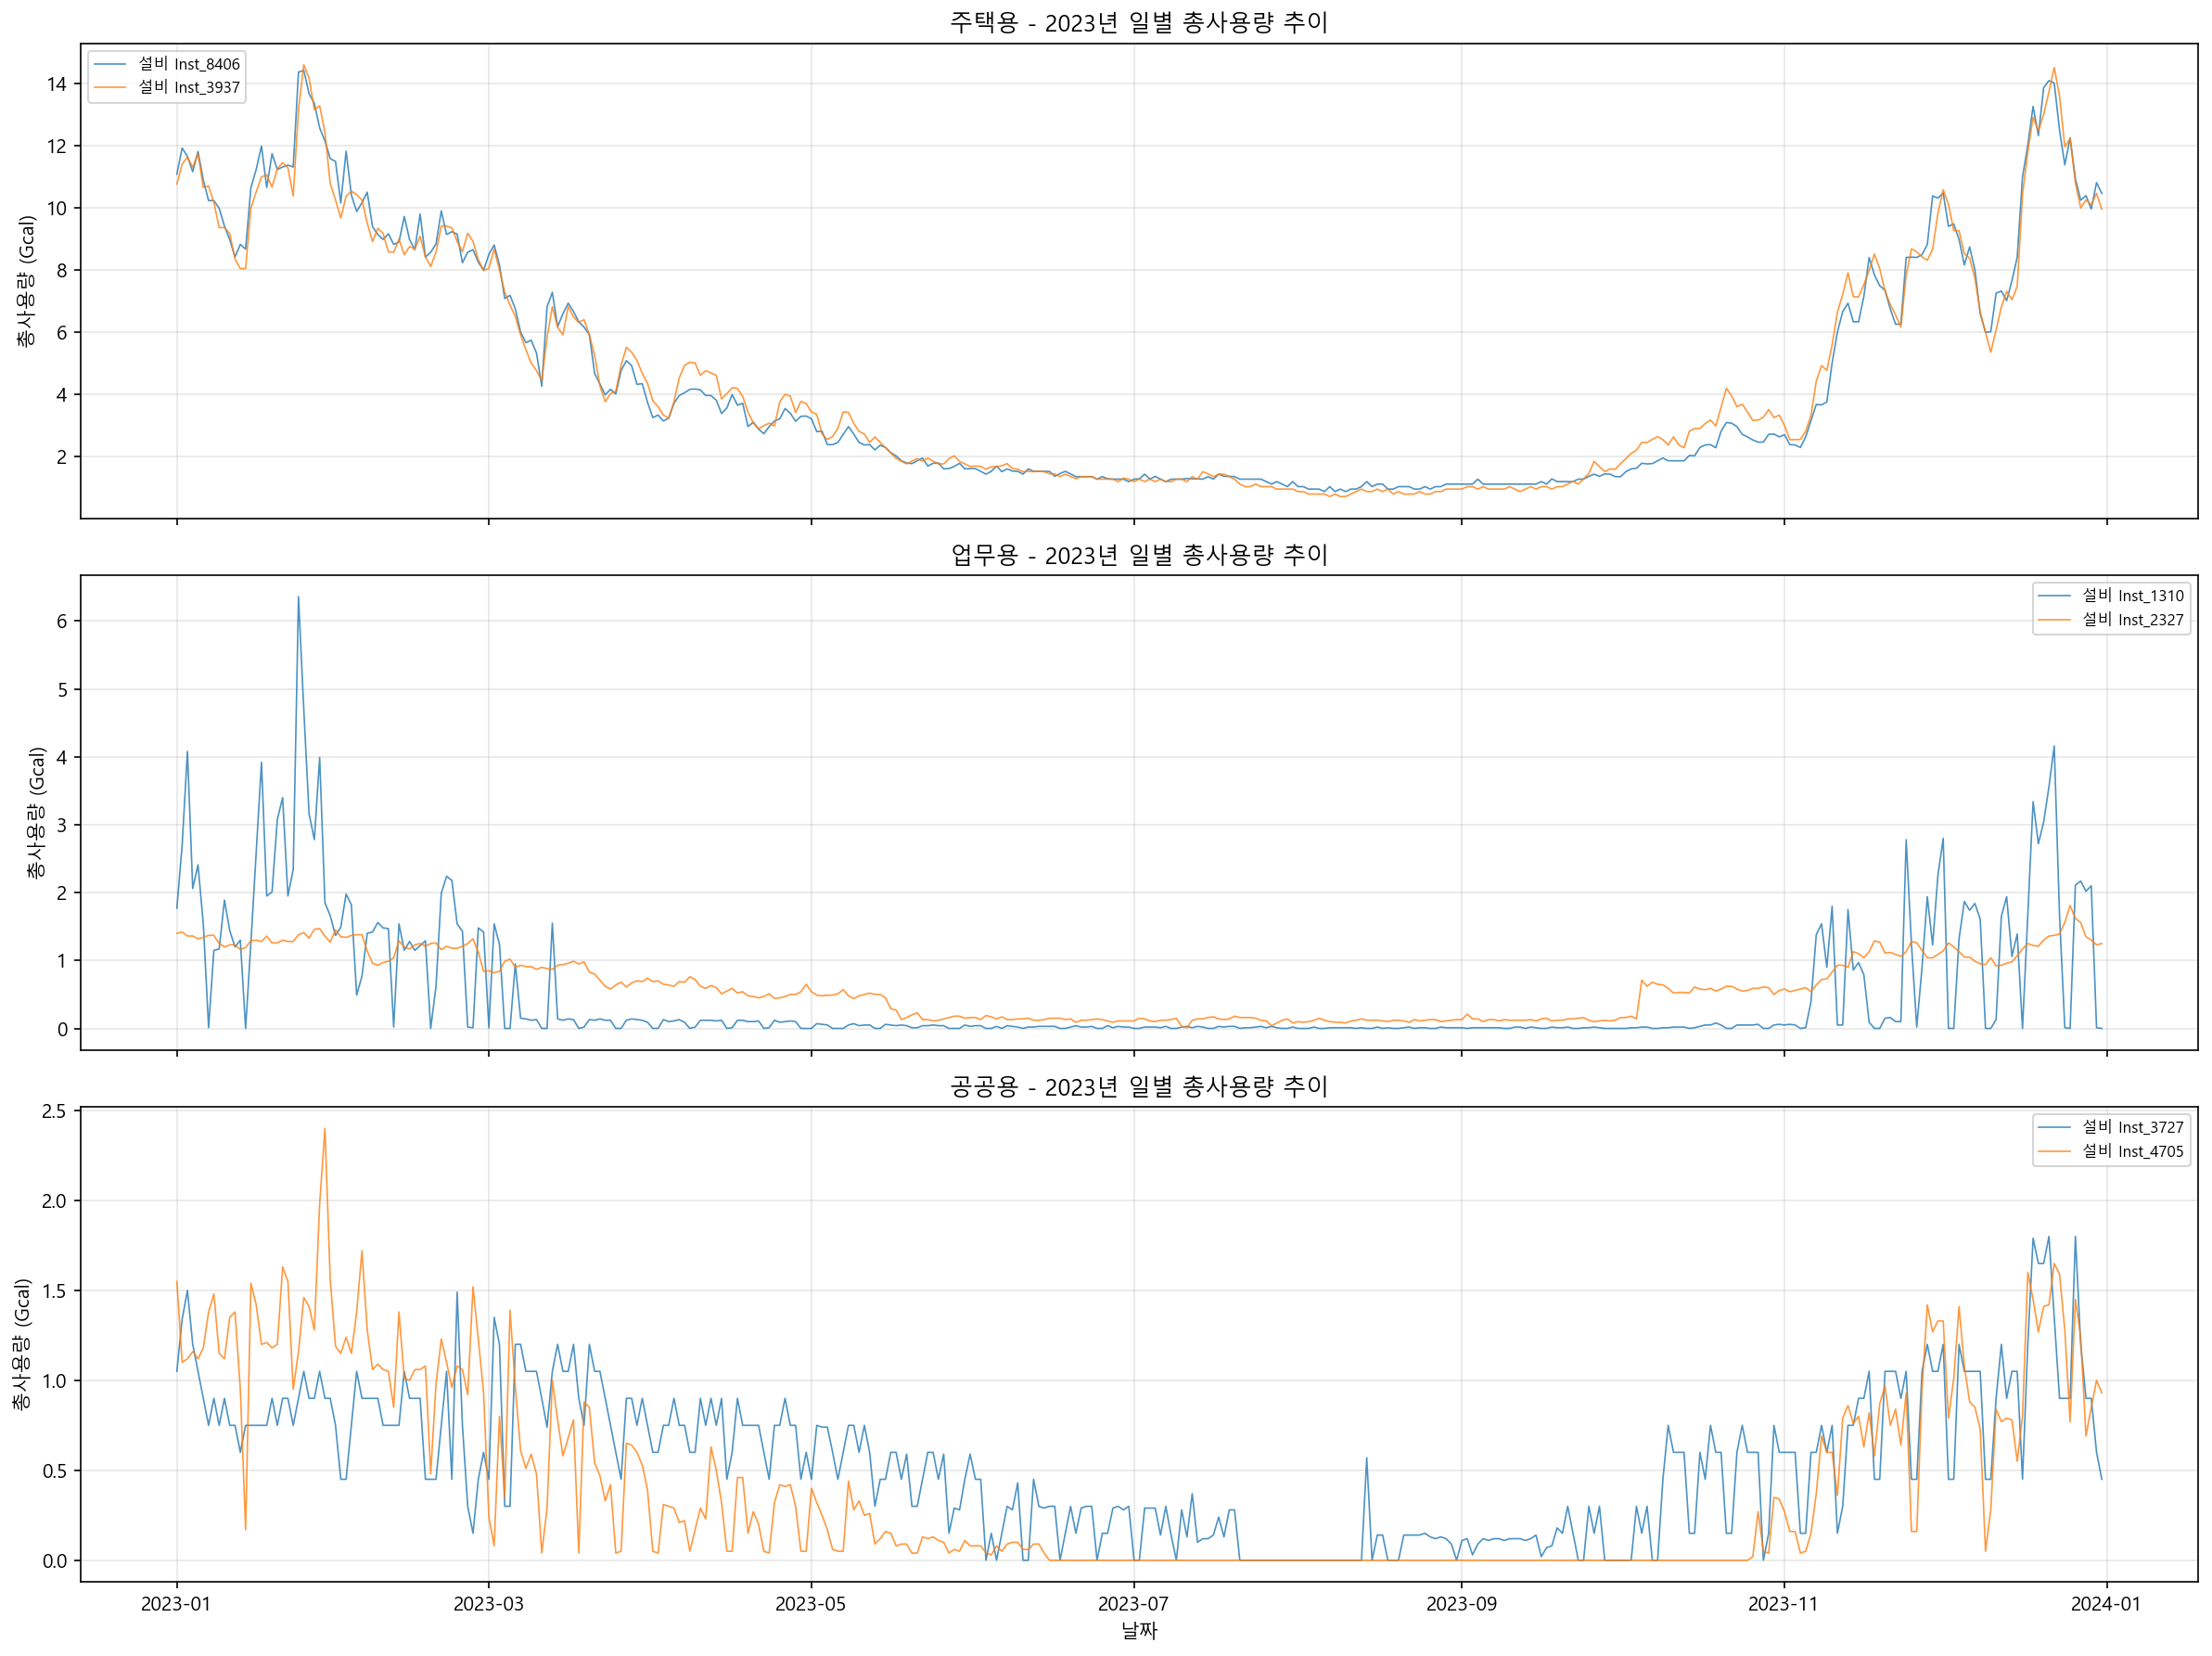

In [10]:
# 대표 설비 선정: 종별별 데이터가 가장 많은(=전 기간 존재) 설비 중 중앙값 근처 사용량 설비
representative = {}
for t in ['주택용', '업무용', '공공용']:
    sub = df[df['종별'] == t]
    # 전 기간(5년) 존재하는 설비
    inst_years = sub.groupby('설치')['연도'].nunique()
    full_inst = inst_years[inst_years == 5].index
    if len(full_inst) == 0:
        full_inst = inst_years[inst_years == inst_years.max()].index
    # 그 중 평균 총사용량이 중앙값 근처인 설비 2개
    avg_usage = sub[sub['설치'].isin(full_inst)].groupby('설치')['총사용량'].mean()
    median_usage = avg_usage.median()
    closest = (avg_usage - median_usage).abs().nsmallest(2).index.tolist()
    representative[t] = closest
    print(f'{t} 대표 설비: {closest} (평균 사용량: {avg_usage[closest].values.round(2)})')

# 시각화: 2023년 1년간 일별 추이
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
year_view = 2023

for idx, t in enumerate(['주택용', '업무용', '공공용']):
    ax = axes[idx]
    for inst in representative[t]:
        sub = df[(df['설치'] == inst) & (df['연도'] == year_view)].sort_values('날짜')
        ax.plot(sub['날짜'], sub['총사용량'], label=f'설비 {inst}', alpha=0.8, linewidth=0.8)
    ax.set_title(f'{t} - {year_view}년 일별 총사용량 추이')
    ax.set_ylabel('총사용량 (Gcal)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('날짜')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_representative_timeseries.png', bbox_inches='tight')
plt.show()

### 평일 vs 주말 사용 패턴 비교

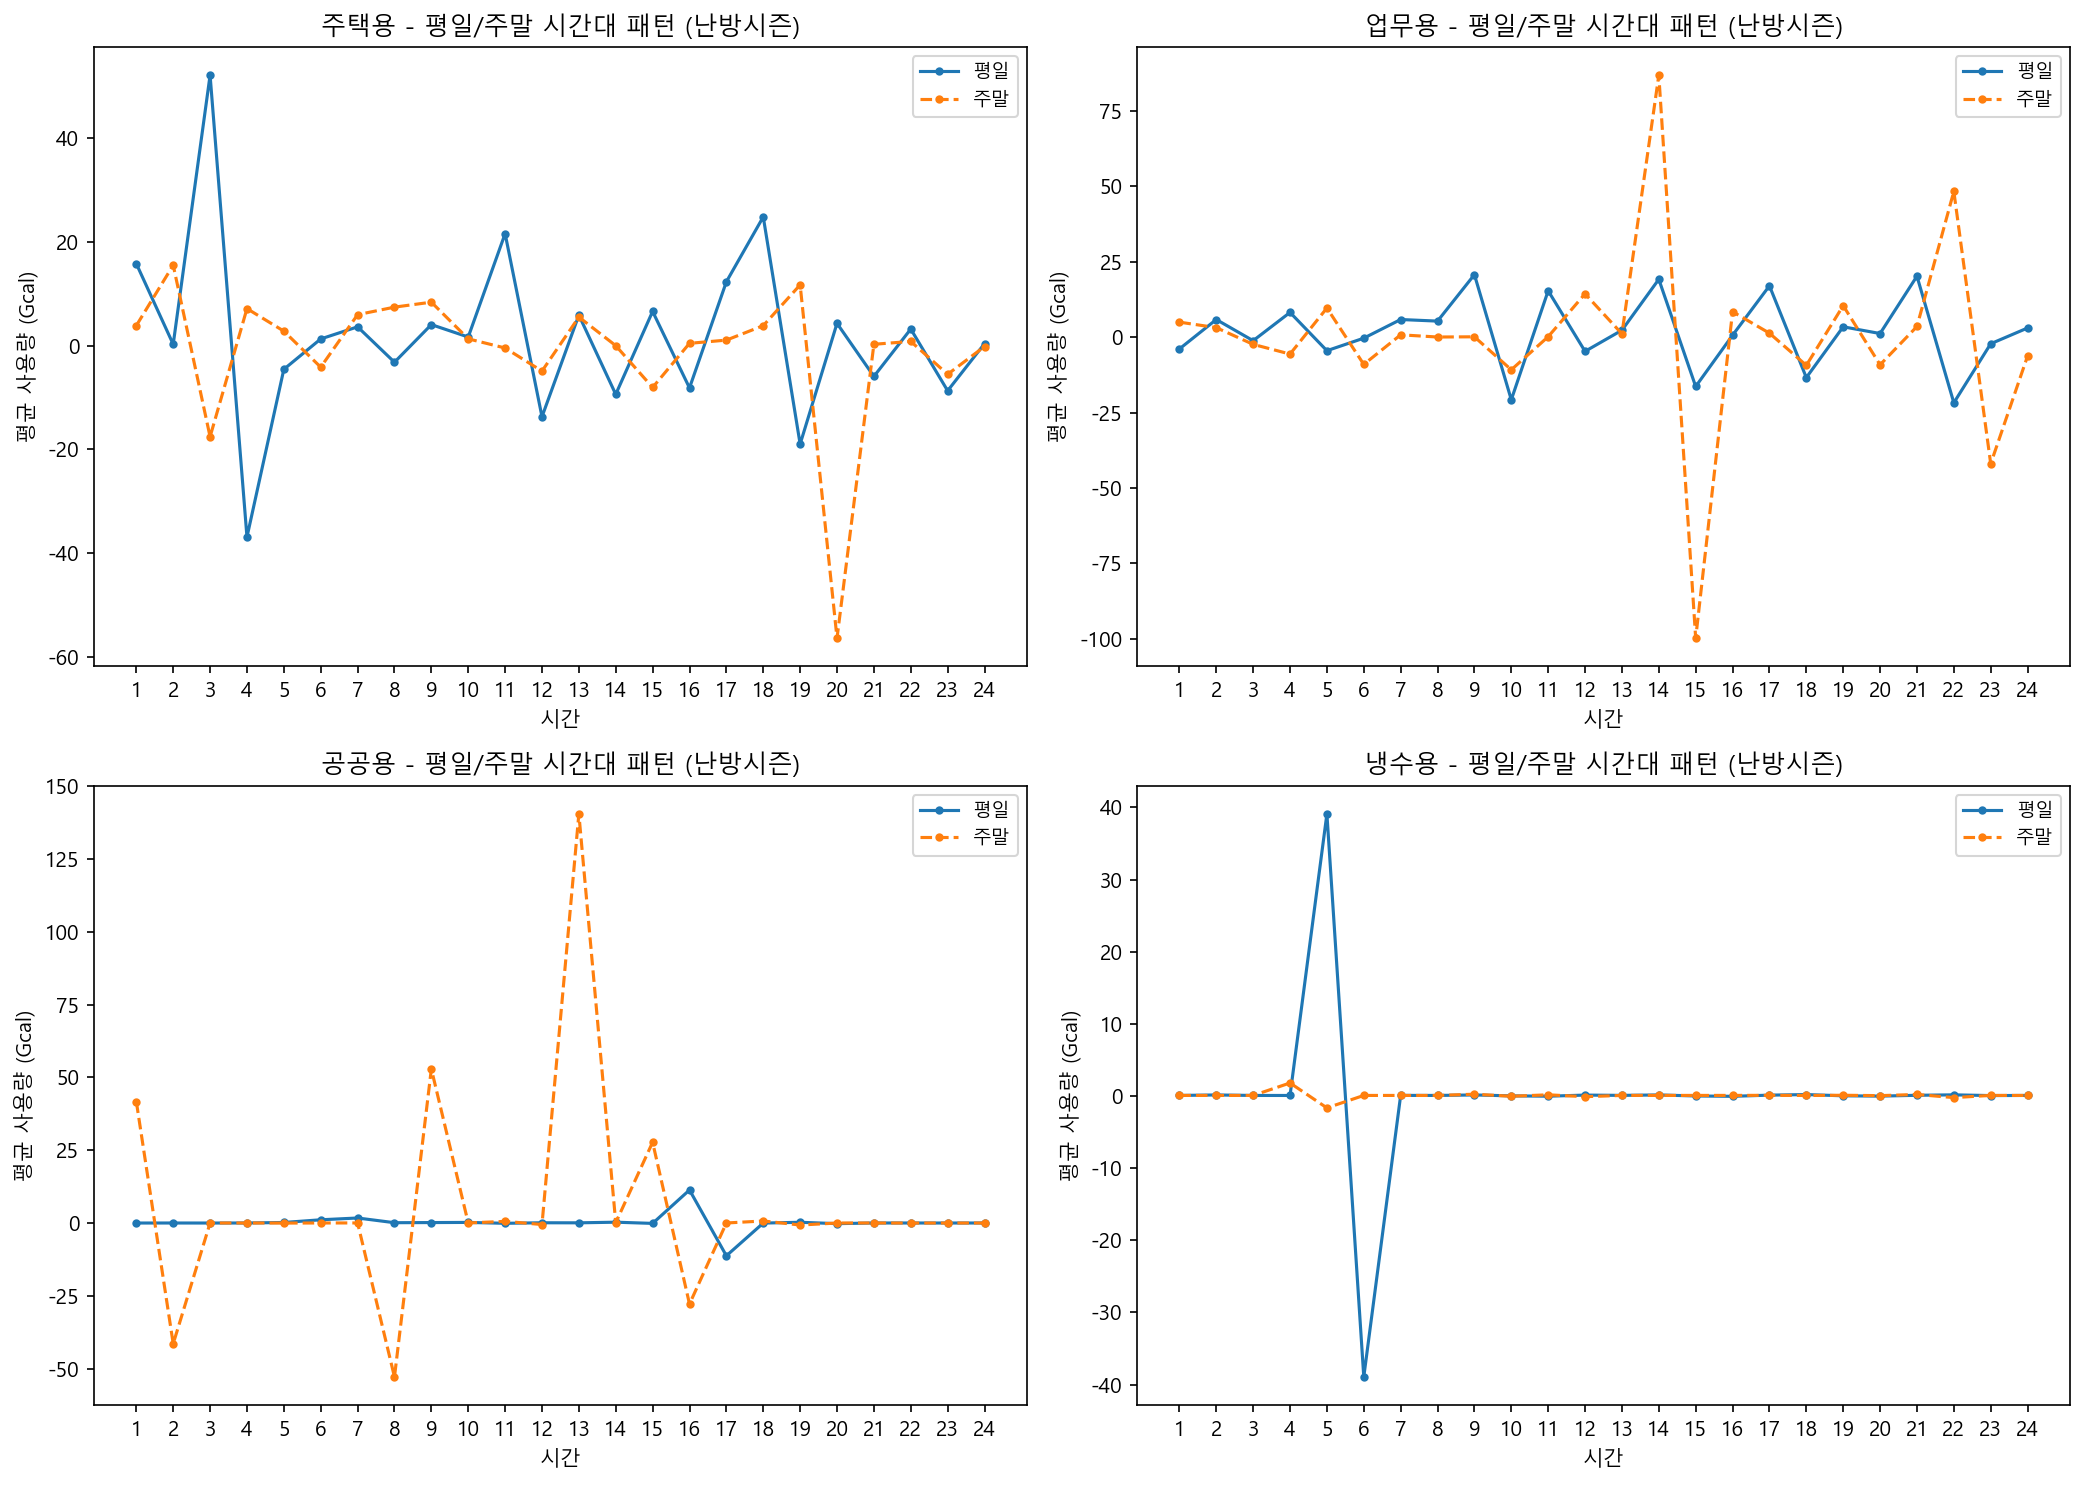

In [11]:
# 평일 vs 주말 시간대 패턴 (난방시즌만, 종별별)
df['주말'] = df['요일'].isin([5, 6])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
heating = df[df['난방시즌']]

for idx, t in enumerate(['주택용', '업무용', '공공용', '냉수용']):
    ax = axes[idx // 2, idx % 2]
    sub = heating[heating['종별'] == t]
    for is_weekend, label, ls in [(False, '평일', '-'), (True, '주말', '--')]:
        vals = sub[sub['주말'] == is_weekend][HOUR_COLS].mean()
        ax.plot(range(1, 25), vals, marker='o', markersize=3, label=label, linestyle=ls)
    ax.set_title(f'{t} - 평일/주말 시간대 패턴 (난방시즌)')
    ax.set_xlabel('시간')
    ax.set_ylabel('평균 사용량 (Gcal)')
    ax.set_xticks(range(1, 25))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_weekday_weekend_pattern.png', bbox_inches='tight')
plt.show()

### 월별(계절별) 총사용량 변화

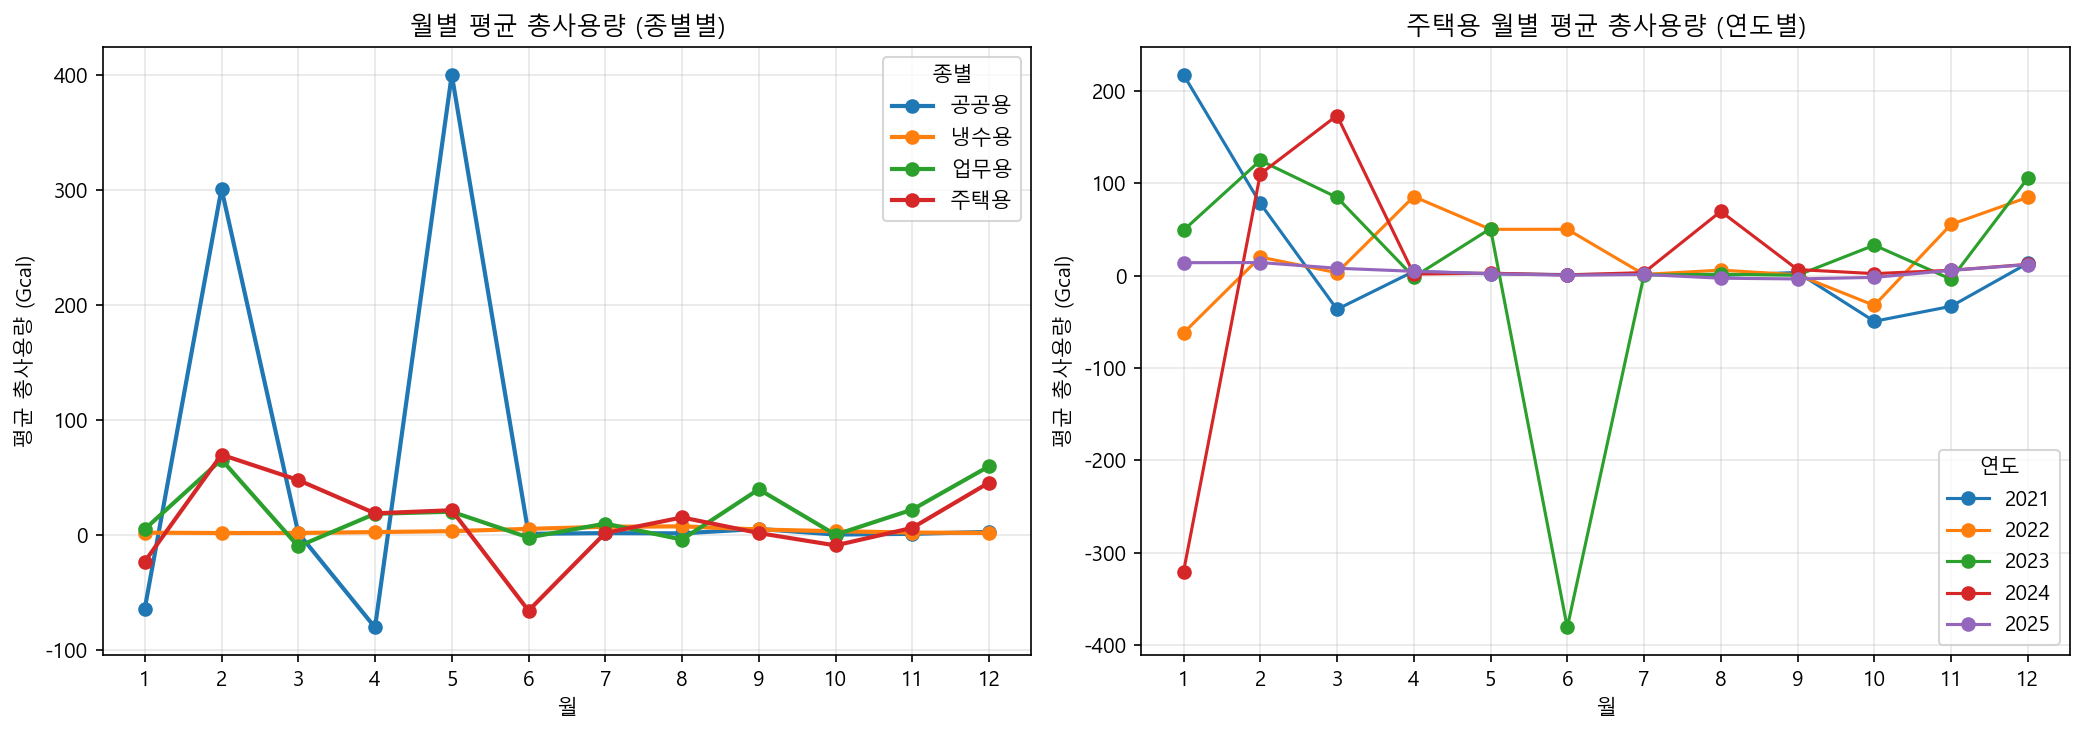

=== 계절별 평균 총사용량 ===


종별      공공용    냉수용     업무용     주택용
계절                                
가을    2.035  3.216  20.267  -0.648
겨울   72.913  1.680  42.928  29.477
봄   108.933  2.379   9.389  29.297
여름    1.199  6.506   1.108 -15.839


In [12]:
# 월별 평균 총사용량 (종별별)
monthly_avg = df.groupby(['월', '종별'])['총사용량'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 절대값
monthly_avg.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('월별 평균 총사용량 (종별별)')
axes[0].set_xlabel('월')
axes[0].set_ylabel('평균 총사용량 (Gcal)')
axes[0].set_xticks(range(1, 13))
axes[0].legend(title='종별')
axes[0].grid(True, alpha=0.3)

# 주택용만 연도별로 분리
monthly_residential = df[df['종별'] == '주택용'].groupby(['연도', '월'])['총사용량'].mean().unstack(level=0)
monthly_residential.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_title('주택용 월별 평균 총사용량 (연도별)')
axes[1].set_xlabel('월')
axes[1].set_ylabel('평균 총사용량 (Gcal)')
axes[1].set_xticks(range(1, 13))
axes[1].legend(title='연도')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_monthly_usage_trend.png', bbox_inches='tight')
plt.show()

# 계절별 평균
print('=== 계절별 평균 총사용량 ===')
season_avg = df.groupby(['계절', '종별'])['총사용량'].mean().unstack()
print(season_avg.round(3).to_string())

### NaN 분포 분석

=== NaN 포함 행 수 ===
전체: 209,894 (1.2%)

행 내 NaN 개수별 분포:
  NaN  1개:   75,375행
  NaN  2개:   12,117행
  NaN  3개:    3,200행
  NaN  4개:    3,047행
  NaN  5개:    3,334행
  NaN  6개:    1,776행
  NaN  7개:    1,367행
  NaN  8개:    1,078행
  NaN  9개:      858행
  NaN 10개:    1,122행
  NaN 11개:    1,462행
  NaN 12개:      789행
  NaN 13개:      720행
  NaN 14개:    1,356행
  NaN 15개:    1,340행
  NaN 16개:      712행
  NaN 17개:      473행
  NaN 18개:      302행
  NaN 19개:      238행
  NaN 20개:      246행
  NaN 21개:    3,451행
  NaN 22개:      208행
  NaN 23개:    3,083행
  NaN 24개:   92,240행

종별별 NaN 행 수:


  업무용: 99,830 (1.5%)


  주택용: 80,824 (1.0%)


  공공용: 27,009 (1.5%)


  냉수용: 2,231 (1.1%)


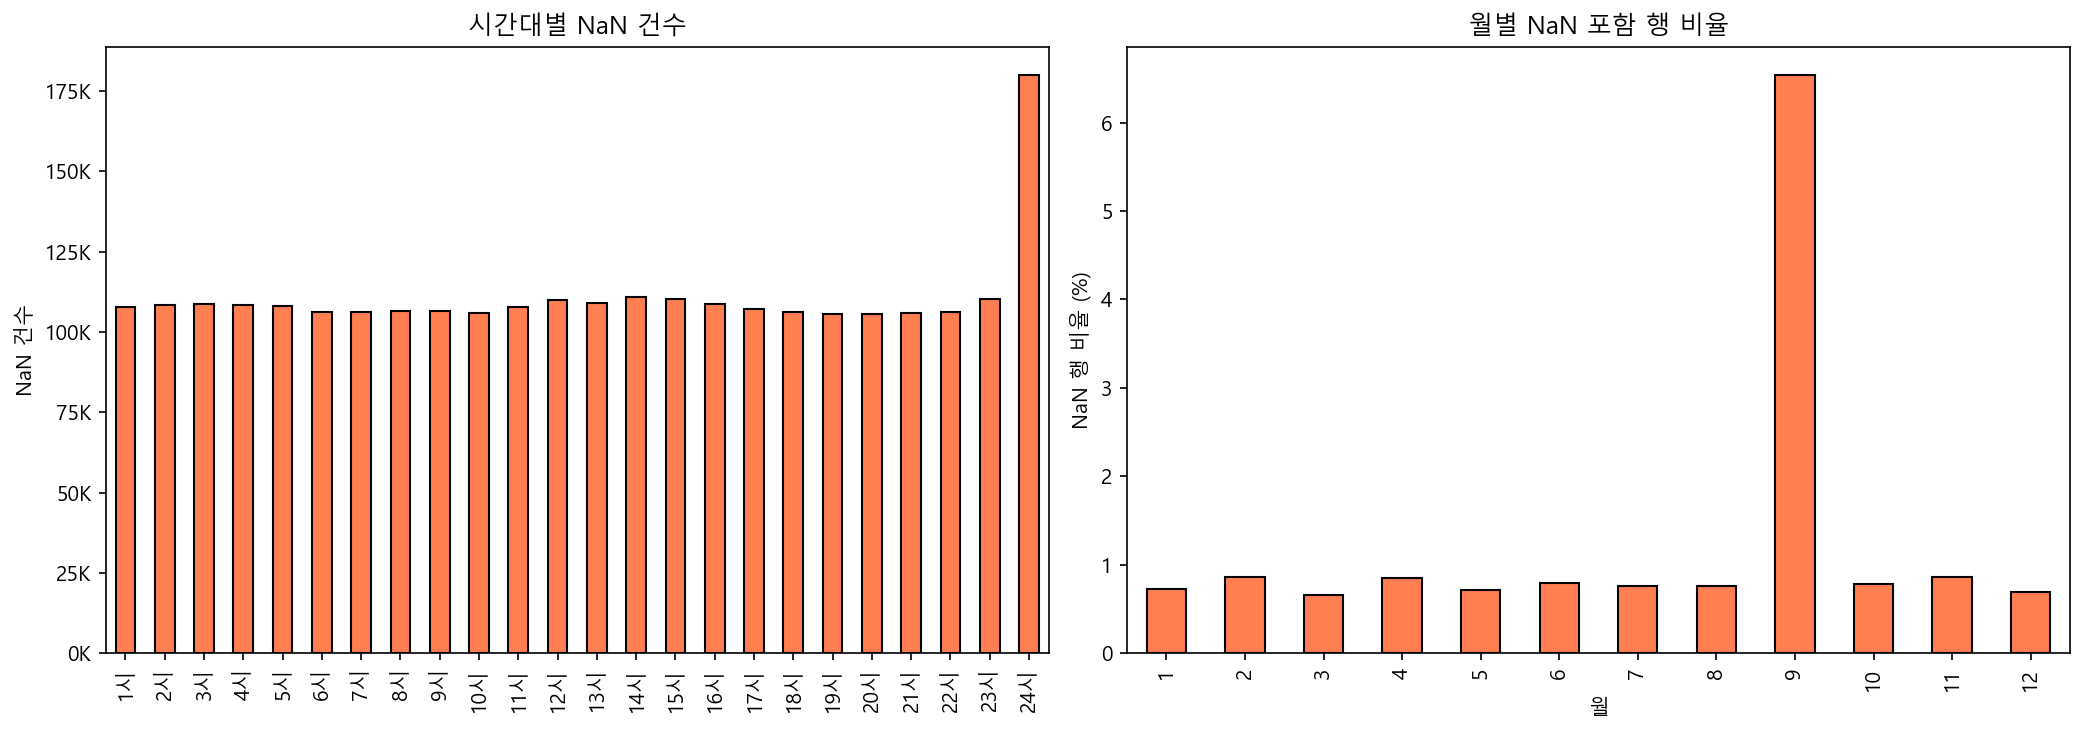

In [13]:
# NaN 분포 분석
nan_per_row = df[HOUR_COLS].isnull().sum(axis=1)
has_nan = nan_per_row > 0

print('=== NaN 포함 행 수 ===')
print(f'전체: {has_nan.sum():,} ({has_nan.mean()*100:.1f}%)')
print(f'\n행 내 NaN 개수별 분포:')
nan_dist = nan_per_row[has_nan].value_counts().sort_index()
for k, v in nan_dist.items():
    print(f'  NaN {k:>2}개: {v:>8,}행')

# NaN 행의 종별 분포
print(f'\n종별별 NaN 행 수:')
nan_by_type = df[has_nan]['종별'].value_counts()
for t in nan_by_type.index:
    total_t = (df['종별'] == t).sum()
    print(f'  {t}: {nan_by_type[t]:,} ({nan_by_type[t]/total_t*100:.1f}%)')

# 시간대별 NaN 비율
nan_by_hour = df[HOUR_COLS].isnull().sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nan_by_hour.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('시간대별 NaN 건수')
axes[0].set_ylabel('NaN 건수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# 월별 NaN 비율
nan_monthly = df.groupby('월').apply(lambda x: x[HOUR_COLS].isnull().any(axis=1).mean() * 100)
nan_monthly.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('월별 NaN 포함 행 비율')
axes[1].set_ylabel('NaN 행 비율 (%)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_nan_distribution.png', bbox_inches='tight')
plt.show()

In [14]:
# 설비 단위 NaN 누적률 (Phase 2 결측치 전략 수립용)
inst_nan_rate = df.groupby('설치').apply(lambda x: x[HOUR_COLS].isnull().any(axis=1).mean() * 100)
print('=== 설비 단위 NaN 행 비율 분포 ===')
print(inst_nan_rate.describe().to_string())

thresholds = [0, 5, 10, 20, 30, 50, 100]
for i in range(len(thresholds) - 1):
    lo, hi = thresholds[i], thresholds[i+1]
    cnt = ((inst_nan_rate >= lo) & (inst_nan_rate < hi)).sum()
    print(f'  NaN비율 {lo}~{hi}%: {cnt}개 설비')

high_nan = inst_nan_rate[inst_nan_rate >= 30]
print(f'\nNaN 30% 이상 설비: {len(high_nan)}개')
if len(high_nan) > 0:
    print(f'  최대: {high_nan.max():.1f}%')
    # 이 설비들의 종별 확인
    high_nan_types = df[df['설치'].isin(high_nan.index)].groupby('설치')['종별'].first()
    print(f'  종별 분포: {high_nan_types.value_counts().to_dict()}')

=== 설비 단위 NaN 행 비율 분포 ===
count    10126.000000
mean         1.431739
std          4.982562
min          0.000000
25%          0.547645
50%          0.602410
75%          0.821468
max        100.000000
  NaN비율 0~5%: 9750개 설비
  NaN비율 5~10%: 181개 설비
  NaN비율 10~20%: 97개 설비
  NaN비율 20~30%: 53개 설비
  NaN비율 30~50%: 15개 설비
  NaN비율 50~100%: 27개 설비

NaN 30% 이상 설비: 45개
  최대: 100.0%


  종별 분포: {'업무용': 26, '공공용': 12, '주택용': 7}


## 1-4. 외부 변수 활용 가능성 판단

지사가 익명화되어 있어 지역별 기온 매칭이 불가능하다. 지사별 사용 패턴의 차이를 확인하여 지역(기후대) 역추정 가능성을 검토한다.

=== 지사 수: 19 ===
              설비수       행수   평균총사용량  중앙값총사용량
지사                                          
Branch_0002  1329  2318429    1.491     0.96
Branch_0008  1240  2154170    2.315     0.72
Branch_0001   908  1592152   44.247     1.79
Branch_0007   798  1260014    2.093     0.29
Branch_0010   764  1197111  107.539     0.72
Branch_0013   734  1295027   -0.666     2.14
Branch_0014   681  1085622    9.796     1.26
Branch_0011   554   957402    4.377     1.88
Branch_0017   438   748938    2.723     0.63
Branch_0009   418   592566    3.728     1.42
Branch_0019   410   669956   12.035     1.30
Branch_0003   348   597492   16.535     0.81
Branch_0006   336   579201    4.877     1.96
Branch_0015   300   532094   47.848     2.22
Branch_0016   260   370383   22.607     2.56
Branch_0018   215   263245    7.291     0.13
Branch_0012   172   280226   11.854     2.05
Branch_0004   116   189311    1.921     0.60
Branch_0005   105   185375    4.380     2.04


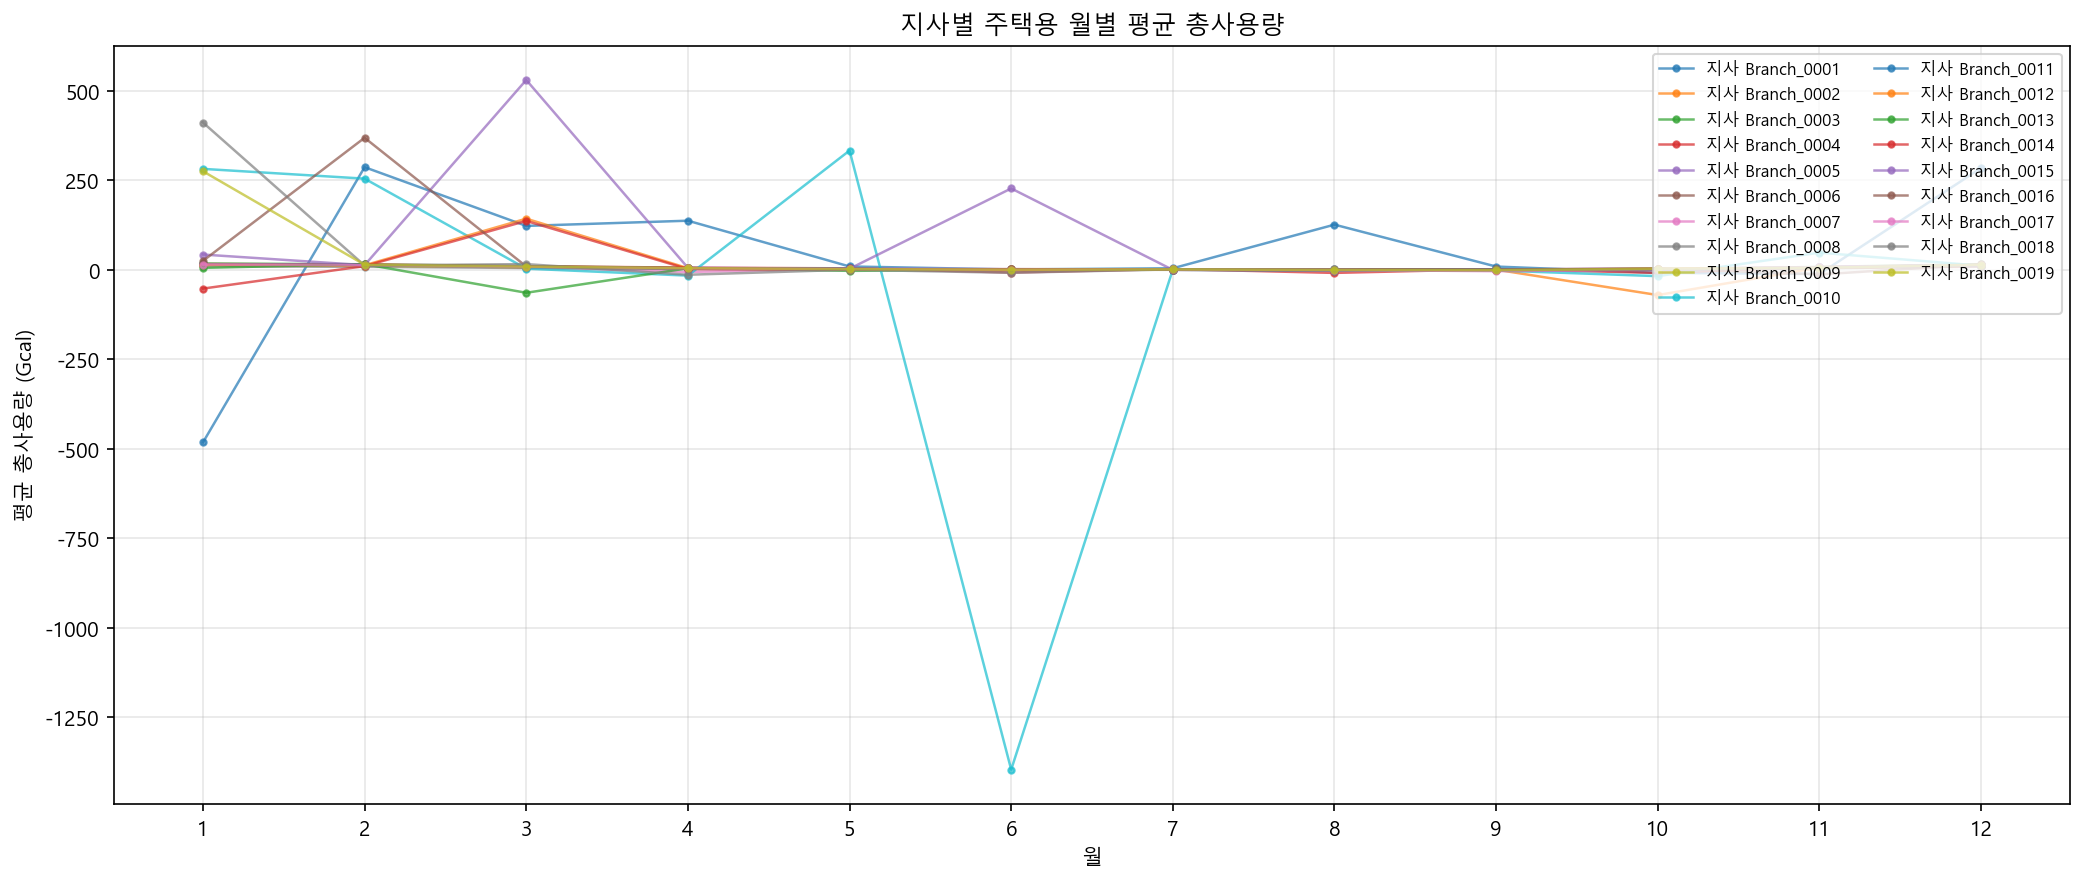


=== 지사별 난방/비난방 사용량 비율 ===
                비난방      난방  난방/비난방 비율
지사                                    
Branch_0001   40.13   37.00       0.92
Branch_0002   -8.81   10.99      -1.25
Branch_0003    1.69   13.84       8.20
Branch_0004   -1.08   13.04     -12.02
Branch_0005    2.46   11.36       4.62
Branch_0006    1.91   11.73       6.14
Branch_0007    1.01   12.01      11.84
Branch_0008    0.84    7.70       9.15
Branch_0009    1.87   10.33       5.51
Branch_0010 -151.65  117.06      -0.77
Branch_0011    1.55   11.90       7.67
Branch_0012    2.15   38.46      17.89
Branch_0013    1.39   -4.81      -3.45
Branch_0014    1.35   22.88      16.95
Branch_0015   33.16  124.08       3.74
Branch_0016    2.32   75.04      32.41
Branch_0017    0.85   11.53      13.55
Branch_0018   -1.98   85.39     -43.22
Branch_0019    1.80   64.97      36.18


In [15]:
# 지사별 기초 정보
branch_stats = df.groupby('지사').agg(
    설비수=('설치', 'nunique'),
    행수=('설치', 'size'),
    평균총사용량=('총사용량', 'mean'),
    중앙값총사용량=('총사용량', 'median')
).sort_values('설비수', ascending=False)

print(f'=== 지사 수: {df["지사"].nunique()} ===')
print(branch_stats.round(3).to_string())

# 지사별 월별 평균 사용량 패턴 (주택용만)
residential = df[df['종별'] == '주택용']
branch_monthly = residential.groupby(['지사', '월'])['총사용량'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
for branch in branch_monthly.index:
    ax.plot(range(1, 13), branch_monthly.loc[branch], marker='o', markersize=3, 
            label=f'지사 {branch}', alpha=0.7, linewidth=1.2)
ax.set_title('지사별 주택용 월별 평균 총사용량')
ax.set_xlabel('월')
ax.set_ylabel('평균 총사용량 (Gcal)')
ax.set_xticks(range(1, 13))
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_branch_monthly_pattern.png', bbox_inches='tight')
plt.show()

# 지사별 난방시즌 vs 비난방시즌 비율로 기후 유사도 판단
branch_ratio = residential.groupby(['지사', '난방시즌'])['총사용량'].mean().unstack()
branch_ratio.columns = ['비난방', '난방']
branch_ratio['난방/비난방 비율'] = branch_ratio['난방'] / branch_ratio['비난방'].replace(0, np.nan)
print('\n=== 지사별 난방/비난방 사용량 비율 ===')
print(branch_ratio.round(2).to_string())

### 지사별 사용량 스케일 차이 확인

지사별 사용량 스케일이 크게 다를 경우, 이상 탐지 시 지사를 컨텍스트 변수로 활용해야 할 수 있다.

=== 지사별 주택용 난방시즌 총사용량 통계 ===
                  평균    중앙값       표준편차  변동계수(CV)
지사                                              
Branch_0001   37.003  10.98  91800.845  2480.887
Branch_0002   10.986   8.74    124.478    11.331
Branch_0003   13.843  11.08     12.367     0.893
Branch_0004   13.036  11.17      9.927     0.762
Branch_0005   11.356  10.16      7.468     0.658
Branch_0006   11.729   8.81     25.743     2.195
Branch_0007   12.011  10.42     63.830     5.314
Branch_0008    7.702   6.24     45.320     5.884
Branch_0009   10.332   8.59     61.706     5.972
Branch_0010  117.062   8.58  80711.219   689.475
Branch_0011   11.902   9.81   2210.491   185.722
Branch_0012   38.459   9.93   5733.254   149.073
Branch_0013   -4.807   9.84   9547.204 -1986.225
Branch_0014   22.883   7.39  14927.714   652.346
Branch_0015  124.076   9.92  56305.473   453.799
Branch_0016   75.039  11.36  39624.438   528.051
Branch_0017   11.529   9.84     26.952     2.338
Branch_0018   85.392   9.56  11291.892  

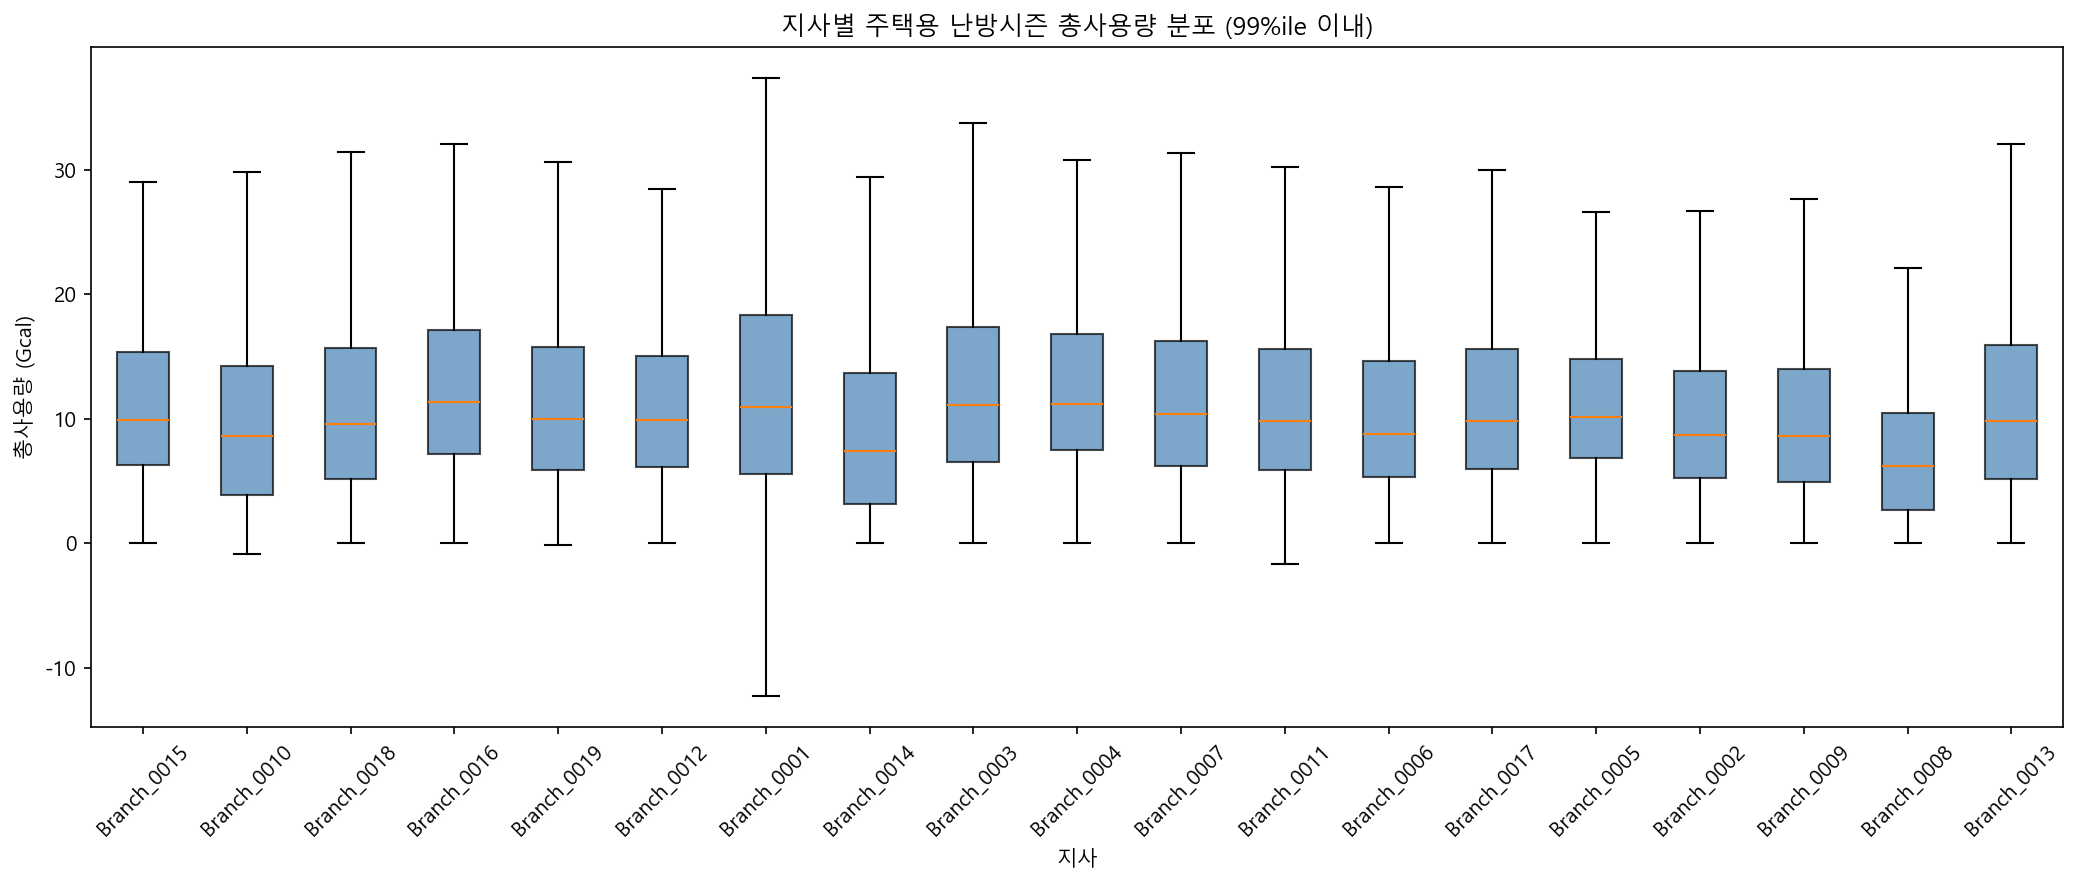

In [16]:
# 지사별 총사용량 분포 (주택용, 난방시즌)
res_heating = df[(df['종별'] == '주택용') & (df['난방시즌'])]
branch_box = res_heating.groupby('지사')['총사용량'].describe()[['mean', '50%', 'std']]
branch_box.columns = ['평균', '중앙값', '표준편차']
branch_box['변동계수(CV)'] = branch_box['표준편차'] / branch_box['평균']
print('=== 지사별 주택용 난방시즌 총사용량 통계 ===')
print(branch_box.round(3).to_string())

# 박스플롯
fig, ax = plt.subplots(figsize=(14, 6))
branches = branch_box.sort_values('평균', ascending=False).index.tolist()
data_for_box = [res_heating[res_heating['지사'] == b]['총사용량'].clip(upper=res_heating['총사용량'].quantile(0.99)) 
                for b in branches]
bp = ax.boxplot(data_for_box, labels=branches, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_title('지사별 주택용 난방시즌 총사용량 분포 (99%ile 이내)')
ax.set_xlabel('지사')
ax.set_ylabel('총사용량 (Gcal)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phase01_branch_usage_boxplot.png', bbox_inches='tight')
plt.show()

## 1-5. EDA 종합 요약 및 의사결정

### 핵심 발견사항

**1. 기초 통계**
- 총 16,868,714행, 설비 10,126대, 지사 수 확인 완료
- 종별 비율: 주택용 8.4M (49.8%), 업무용 6.5M (38.3%), 공공용 1.8M (10.6%), 냉수용 0.2M (1.3%)
- 설비 수 증가 추세 (2021: 8,895 → 2025: 9,883)

**2. 사용량 분포**
- 종별 간 스케일 차이 큼 → **종별별 분리 분석 필수**
- 업무용 제로 37.4%, 공공용 34.8%, 냉수용 52.8% → 비난방시즌 제로가 대부분
- 주택용 제로 1.7% → 상대적으로 안정적
- 음수값: 6,604행(0.04%)으로 극소수이나 극단값 존재 (min=-73M Gcal), 검침 오류로 추정
- 99.9%ile: 주택용 63.4, 업무용 51.2, 공공용 81.8, 냉수용 73.7 Gcal

**3. 시계열 패턴**
- 모든 종별에서 난방시즌/비난방시즌 차이 극명
- 업무용·공공용: 평일/주말 차이 두드러짐 (주말 사용량 감소)
- 주택용: 평일/주말 차이 상대적으로 작음
- NaN: 전체 설비 96%가 NaN 비율 5% 미만, 30% 이상은 45개 설비(업무용 26, 공공용 12, 주택용 7)

**4. 외부 변수**
- 지사 익명화로 기온 직접 매칭 불가
- 지사별 사용량 스케일 차이 존재 → 지사를 컨텍스트 변수로 활용
- **결정: 기온 변수 미사용, 월/계절로 대체 (방법 C)**

### Phase 2 이후 파라미터 확정

| 항목 | 확정값 | 근거 |
|------|--------|------|
| 음수값 처리 | 음수값 포함 행 제거 (6,604행, 0.04%) | 극단적 검침 오류, 보정 불가 |
| 극단값 threshold | 종별별 99.9%ile 기반 상한 clip | 주택용 63.4, 업무용 51.2, 공공용 81.8, 냉수용 73.7 |
| NaN ≤3개 행 | 행 내 시간 보간 (선형) | 전후 시간대 연속성 |
| NaN 4~12개 행 | 행 제거 | 보간 신뢰도 낮음 |
| NaN ≥13개 행 | 행 제거 | Phase 0에서 식별된 104K행 |
| NaN 30%+ 설비 | 분석 대상에서 제외 (45개) | 데이터 품질 미달 |
| 비난방시즌 데이터 | 포함, 난방시즌 flag로 구분 | 업무용·냉수용 비난방 패턴 존재 |
| 기온 변수 | 미사용 (월/계절 대체) | 지사 익명화 |
| 지사 변수 | 컨텍스트 변수로 활용 | 지사별 스케일 차이 |
| 냉수용 처리 | 별도 분석 또는 제외 검토 | 데이터 극소수(1.3%), 제로 52.8% |